# New adaptive point selection — robust fitting with sigma-clipping

## Problems with the original RSS-based sweep

**Problem 1 — bias toward minimum points:**  
Plain RSS grows as you add more points (more terms in the sum), so the optimizer always prefers using fewer points. We need a metric that *normalizes* by point count.

**Problem 2 — physically anomalous points:**  
Some points inside an injection span deviate from the exponential decay due to plasma instabilities. We know the true decay *must* be exponential (physics), so those points are measurement artifacts — not signal — and should be excluded.

## Proposed solutions

| Problem | Solution |
|---|---|
| RSS min-points bias | Use **reduced χ²** = RSS / (n − 2). Normalizes by degrees of freedom; adding a well-fitting point can only improve the score. |
| Anomalous / outlier points | **Iterative sigma-clipping**: fit on all injection points → compute residuals → remove points where \|r\| > k·MAD → refit → repeat until stable. Uses `scipy.optimize.least_squares` with `loss='soft_l1'` for the initial robust estimate. |

MAD (median absolute deviation) is the standard robust scatter estimator used in experimental physics and astronomy pipelines.


# __init__

In [2]:
"""Cell 1 — Setup: imports, project root, load discharge, detect injections."""
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit

# --- locate project root so pha_lib is importable ---
def _find_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pha_lib").exists():
            return p
    raise FileNotFoundError("pha_lib not found")

ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pha_lib import io
from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

# --- parameters ---
DISCHARGE_DIR = ROOT / "data" / "discharges" / "2025-04-29--10-19"
CHANNEL_ID    = 2
LINE_E        = 6660.0   # eV
HALF_W        = 60.0     # eV half-window

In [ ]:
# --- load discharge and detect injections ---
discharge  = io.load_test_folder(DISCHARGE_DIR, discharge_id="2025-04-29--10-19")
channel    = discharge.channels[CHANNEL_ID]
trace      = integrate_energy_window(channel, LINE_E, HALF_W)
injections = detect_injections(trace, LINE_E)

print(f"Loaded: {discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(injections)} injection(s) detected")
for inj in injections:
    print(f"  #{inj.injection_no}  frames {inj.start_frame}..{inj.finish_frame}  "
          f"(span={inj.finish_frame - inj.start_frame})")

# work on the first injection
injection = injections[0]
print(f"\nWorking on injection #{injection.injection_no}  "
      f"(start={injection.start_frame}, finish={injection.finish_frame})")


Loaded: 2025-04-29--10-19
Channel 2: 4 injection(s) detected
  #1  frames 98..106  (span=8)
  #2  frames 145..153  (span=8)
  #3  frames 192..200  (span=8)
  #4  frames 279..287  (span=8)

Working on injection #1  (start=98, finish=106)


In [3]:
"""Cell 2 — Core fitting helpers.

find_first_falling_frame():
  Returns the first frame of the LAST descent inside the injection span.
  For roller-coaster injections (events oscillate up-down before the final
  decay), this finds the last local maximum and returns the frame after it —
  i.e., the start of the final exponential decay.
  Falls back to start_frame+1 if no falling step is found.

fit_sigma_clip()  [log-space version]:
  1. Auto-detect t_0 using find_first_falling_frame().
  2. Transform y → z = ln(y − C_bg).  In log space the exponential becomes
     a straight line z = m·t + b  (m = −1/τ), so ALL points have equal
     leverage — high-leverage masking cannot occur.
  3. Initial seed: np.polyfit on all valid (y > C_bg) points in log space.
  4. Iterative sigma-clipping: fit → log-space residuals → MAD → reject →
     refit until the inlier set is stable.
  5. Final OLS in original space (curve_fit) on the stable inlier set to
     obtain proper parameter errors.

Returns a dict with fit params, covariance, inlier mask, and quality metrics.
"""

_MAD_SCALE = 1.4826   # makes MAD equivalent to 1-sigma for Gaussian noise


def _exp_model(t, A, tau, t_0, C_bg):
    """Exponential decay: A * exp(-(t - t_0) / tau) + C_bg."""
    return A * np.exp(-(t - t_0) / tau) + C_bg


def _initial_guess(y_fit, t_0, C_bg):
    """Simple initial guess: A from first point above background, tau=1."""
    A0 = max(float(y_fit[0] - C_bg), 1.0)
    return [A0, 1.0]


def find_first_falling_frame(trace, injection) -> int:
    """Return the first frame of the LAST descent inside the injection span.

    For injections with roller-coaster oscillations (events go up-down
    several times before the final exponential decay), the current span may
    contain multiple local maxima.  This function finds the LAST local
    maximum and returns the frame immediately after it — the start of the
    final, physically meaningful decay.

    A local maximum at index i is defined as:
      v[i] >= v[i-1]  (or i is the first span point)
      v[i] >  v[i+1]

    Falls back to the first falling frame (original behaviour) if no local
    maximum is found in the interior, then to start_frame+1 if the span is
    monotonically non-decreasing.
    """
    fn = trace.frame_numbers
    v  = trace.values

    try:
        s_idx = int(np.where(fn == int(injection.start_frame))[0][0])
    except IndexError:
        return int(injection.start_frame + 1)

    try:
        e_idx = int(np.where(fn == int(injection.finish_frame))[0][0])
    except IndexError:
        e_idx = len(fn) - 1

    # --- find last local maximum in [s_idx, e_idx-1] ---
    # Scan forward; keep updating last_peak_idx every time a local max is found.
    # At the end, last_peak_idx holds the rightmost peak (last roller-coaster top).
    last_peak_idx = None
    for i in range(s_idx, e_idx):
        # local max condition: not lower than the previous point, and higher than next
        not_lower_than_prev = (i == s_idx) or (v[i] >= v[i - 1])
        higher_than_next    = v[i] > v[i + 1]
        if not_lower_than_prev and higher_than_next:
            last_peak_idx = i   # keep updating — we want the last one

    if last_peak_idx is not None:
        next_idx = last_peak_idx + 1
        if next_idx <= e_idx:
            # first falling frame of the final decay
            return int(fn[next_idx])

    # fallback 1: first falling step anywhere in the span (original behaviour)
    for i in range(s_idx + 1, e_idx + 1):
        if v[i] < v[i - 1]:
            return int(fn[i])

    # fallback 2: monotonically non-decreasing — use original convention
    return int(injection.start_frame + 1)


def fit_sigma_clip(
    trace,
    injection,
    sigma_thresh: float = 1,
    max_iter: int = 10,
    min_inliers: int = 4,
    #HACK: take initial variables from coonfig.py
) -> dict:
    """Robust iterative sigma-clipping fit in log space over the injection decay span.

    The exponential model  y = A·exp(−(t−t₀)/τ) + C_bg  becomes linear in
    log space after subtracting the background:

        z = ln(y − C_bg) = ln(A) − (t − t₀)/τ  =  m·t + b

    where  m = −1/τ  and  b = ln(A) + t₀/τ.

    Using linear regression (np.polyfit) in log space instead of nonlinear
    curve_fit means ALL points have equal leverage.  Early points near t₀
    cannot mask themselves — the high-leverage masking problem is eliminated.

    Parameters
    ----------
    trace          : TimeTrace with .frame_numbers and .values
    injection      : Injection with .start_frame and .finish_frame
    sigma_thresh   : outlier threshold in units of MAD (applied to log-space residuals)
    max_iter       : maximum number of sigma-clip iterations
    min_inliers    : minimum inliers required to keep a fit valid

    Returns
    -------
    dict with keys:
      success, A, tau, t_0, C_bg, A_err, tau_err,
      inlier_mask (bool array over injection span),
      n_total, n_inliers, inlier_fraction,
      rss_inliers, rmse_inliers, reduced_chi2,
      tau_err_rel, message, iterations
    """
    fn = trace.frame_numbers
    v  = trace.values

    # t_0: first frame of the last descent (handles roller-coaster injections)
    t_0  = float(find_first_falling_frame(trace, injection))
    C_bg = float(np.median(v))

    # --- locate the decay span in the trace: from t_0 to finish_frame ---
    try:
        start_idx = int(np.where(fn == int(t_0))[0][0])
    except IndexError:
        return _fail(f"t_0={int(t_0)} not in trace", t_0, C_bg)

    try:
        end_idx = int(np.where(fn == int(injection.finish_frame))[0][0]) + 1
    except IndexError:
        end_idx = len(fn)
    end_idx = max(end_idx, start_idx + min_inliers)

    t_all   = fn[start_idx:end_idx].astype(float)
    y_all   = v[start_idx:end_idx].astype(float)
    n_total = len(t_all)

    if n_total < min_inliers:
        return _fail(f"decay span too short ({n_total} pts)", t_0, C_bg)

    # --- Step 0: mark points where y > C_bg (log is only defined there) ---
    valid_mask = y_all > C_bg
    if valid_mask.sum() < min_inliers:
        return _fail(f"too few points above C_bg ({valid_mask.sum()})", t_0, C_bg)

    # log-transformed signal: z_i = ln(y_i - C_bg)
    # Safe: clamp to a tiny positive value for invalid points so array shapes match;
    # those entries are excluded by valid_mask / inlier_mask and never used in fits.
    z_all = np.where(valid_mask, np.log(np.maximum(y_all - C_bg, 1e-300)), np.nan)

    # --- Step 1: initial log-space linear seed ---
    # polyfit on all valid points gives an unbiased starting slope and intercept
    t_valid = t_all[valid_mask]
    z_valid = z_all[valid_mask]
    try:
        m_seed, b_seed = np.polyfit(t_valid, z_valid, 1)
        # physics requires decay → slope must be negative
        if m_seed >= 0:
            m_seed = -0.1
    except Exception:
        m_seed = -0.1
        b_seed = float(np.log(max(y_all[0] - C_bg, 1.0)))

    m_fit, b_fit = m_seed, b_seed   # will be updated each iteration

    # --- Step 2: iterative sigma-clipping in log space ---
    # Because log-space regression is linear, all points have equal leverage.
    # Residuals r_i = z_i - z_hat_i are relative errors, so early steep points
    # are not unfairly penalised or masked.
    inlier_mask = valid_mask.copy()

    for iteration in range(max_iter):
        t_in = t_all[inlier_mask]
        z_in = z_all[inlier_mask]

        if len(t_in) < min_inliers:
            break

        try:
            m_fit, b_fit = np.polyfit(t_in, z_in, 1)
            if m_fit >= 0:
                # slope turned non-negative — physically invalid, revert
                m_fit = m_seed
        except Exception:
            break

        # log-space residuals over ALL valid points (not just inliers)
        z_pred_all = m_fit * t_all + b_fit
        resid_all  = z_all - z_pred_all   # nan where y <= C_bg

        # MAD of residuals among current inliers — robust scatter estimate
        mad = _MAD_SCALE * np.median(np.abs(resid_all[inlier_mask]))
        if mad < 1e-12:
            break   # perfectly flat log residuals — converged

        # keep points within sigma_thresh * MAD AND that are log-valid
        new_mask = (np.abs(resid_all) <= sigma_thresh * mad) & valid_mask

        # never drop below min_inliers
        if new_mask.sum() < min_inliers:
            new_mask = inlier_mask   # revert

        if np.array_equal(new_mask, inlier_mask):
            inlier_mask = new_mask
            break   # converged — inlier set unchanged

        inlier_mask = new_mask
        m_seed = m_fit

    # --- Step 3: final OLS fit in ORIGINAL space on the stable inlier set ---
    # curve_fit in original space gives proper parameter covariance / errors.
    # The log-space solution provides a very good initial guess.
    t_in = t_all[inlier_mask]
    y_in = y_all[inlier_mask]
    n_in = int(inlier_mask.sum())

    if n_in < min_inliers:
        return _fail(f"too few inliers ({n_in}) after clipping", t_0, C_bg)

    # recover tau and A from the log-space slope/intercept as initial guess
    tau_seed = max(-1.0 / m_fit, 0.01) if m_fit < 0 else 1.0
    A_seed   = max(float(np.exp(b_fit + m_fit * t_0)), 1e-6)

    try:
        popt, pcov = curve_fit(
            lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
            t_in, y_in,
            p0=[A_seed, tau_seed],
            maxfev=5000,
        )
    except Exception as exc:
        return _fail(f"final fit failed: {exc}", t_0, C_bg)

    A_fit, tau_fit = float(popt[0]), float(popt[1])

    # 1-sigma errors from covariance diagonal
    diag = np.diag(pcov).astype(float)
    diag[diag < 0] = np.nan
    A_err, tau_err = float(np.sqrt(diag[0])), float(np.sqrt(diag[1]))

    # quality metrics on inliers (in original space)
    resid_in = y_in - _exp_model(t_in, A_fit, tau_fit, t_0, C_bg)
    rss      = float(np.sum(resid_in ** 2))
    dof      = n_in - 2               # 2 free params (A, tau)
    rmse     = float(np.sqrt(rss / n_in))
    red_chi2 = float(rss / dof) if dof > 0 else np.nan

    return {
        "success":          True,
        "A":                A_fit,
        "tau":              tau_fit,
        "t_0":              t_0,
        "C_bg":             C_bg,
        "A_err":            A_err,
        "tau_err":          tau_err,
        "inlier_mask":      inlier_mask,
        "t_all":            t_all,
        "y_all":            y_all,
        "n_total":          n_total,
        "n_inliers":        n_in,
        "inlier_fraction":  n_in / n_total,
        "rss_inliers":      rss,
        "rmse_inliers":     rmse,
        "reduced_chi2":     red_chi2,
        "tau_err_rel":      tau_err / abs(tau_fit) if tau_fit != 0 else np.nan,
        "message":          f"ok (t_0={int(t_0)}, iter={iteration+1}, inliers={n_in}/{n_total})",
        "iterations":       iteration + 1,
    }


def _fail(msg, t_0, C_bg):
    """Return a standardized failure dict."""
    nan = float("nan")
    return {
        "success": False, "message": msg,
        "A": nan, "tau": nan, "t_0": t_0, "C_bg": C_bg,
        "A_err": nan, "tau_err": nan,
        "inlier_mask": None, "t_all": None, "y_all": None,
        "n_total": 0, "n_inliers": 0, "inlier_fraction": nan,
        "rss_inliers": nan, "rmse_inliers": nan,
        "reduced_chi2": nan, "tau_err_rel": nan, "iterations": 0,
    }


print("find_first_falling_frame() and fit_sigma_clip() [log-space] defined.")


find_first_falling_frame() and fit_sigma_clip() [log-space] defined.


# Testing sigma-clip

In [ ]:
"""Cell 3 — Run sigma-clip fit on injection #1 of discharge 2025-04-29--10-19 and print quality metrics."""

result = fit_sigma_clip(trace, injection, sigma_thresh=2.5)

if result["success"]:
    print("=== Sigma-clip fit result ===")
    print(f"  A         = {result['A']:.4f}  ± {result['A_err']:.4f}")
    print(f"  tau       = {result['tau']:.4f}  ± {result['tau_err']:.4f}  "
          f"(rel err = {result['tau_err_rel']*100:.1f}%)")
    print(f"  t_0       = {result['t_0']:.1f}  (fixed)")
    print(f"  C_bg      = {result['C_bg']:.4f}  (fixed)")
    print(f"")
    print(f"  Inliers   = {result['n_inliers']} / {result['n_total']}  "
          f"({result['inlier_fraction']*100:.0f}%)")
    print(f"  RSS       = {result['rss_inliers']:.4g}  (on inliers)")
    print(f"  RMSE      = {result['rmse_inliers']:.4g}  (= sqrt(RSS/n))")
    print(f"  red. χ²   = {result['reduced_chi2']:.4g}  (= RSS/(n-2))")
    print(f"  τ rel err = {result['tau_err_rel']*100:.2f}%")
    print(f"  Message   : {result['message']}")
else:
    print(f"Fit failed: {result['message']}")


=== Sigma-clip fit result ===
  A         = 1321.5429  ± 49.9974
  tau       = 1.4963  ± 0.1088  (rel err = 7.3%)
  t_0       = 100.0  (fixed)
  C_bg      = 102.0000  (fixed)

  Inliers   = 7 / 7  (100%)
  RSS       = 1.341e+04  (on inliers)
  RMSE      = 43.77  (= sqrt(RSS/n))
  red. χ²   = 2682  (= RSS/(n-2))
  τ rel err = 7.27%
  Message   : ok (t_0=100, iter=1, inliers=7/7)


In [ ]:
"""Cell 4 — Sweep sigma_thresh values; compare metrics to see which threshold is best."""

thresholds = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
sweep_rows = []

for th in thresholds:
    r = fit_sigma_clip(trace, injection, sigma_thresh=th)
    sweep_rows.append({
        "sigma_thresh":     th,
        "success":          r["success"],
        "n_inliers":        r["n_inliers"],
        "n_total":          r["n_total"],
        "inlier_frac_%":    round(r["inlier_fraction"] * 100, 1),
        "tau":              round(r["tau"], 4) if r["success"] else float("nan"),
        "tau_err":          round(r["tau_err"], 4) if r["success"] else float("nan"),
        "tau_rel_err_%":    round(r["tau_err_rel"] * 100, 2) if r["success"] else float("nan"),
        "RMSE":             round(r["rmse_inliers"], 4) if r["success"] else float("nan"),
        "red_chi2":         round(r["reduced_chi2"], 4) if r["success"] else float("nan"),
    })

df_sweep = pd.DataFrame(sweep_rows)
print("Threshold sweep on injection #1:")
print(df_sweep.to_string(index=False))


Threshold sweep on injection #1:
 sigma_thresh  success  n_inliers  n_total  inlier_frac_%    tau  tau_err  tau_rel_err_%    RMSE  red_chi2
          1.5     True          4        7           57.1 1.3473   0.0170           1.26  4.7642   45.3948
          2.0     True          5        7           71.4 1.3632   0.0283           2.08  9.1950  140.9145
          2.5     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          3.0     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          3.5     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          4.0     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          5.0     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361


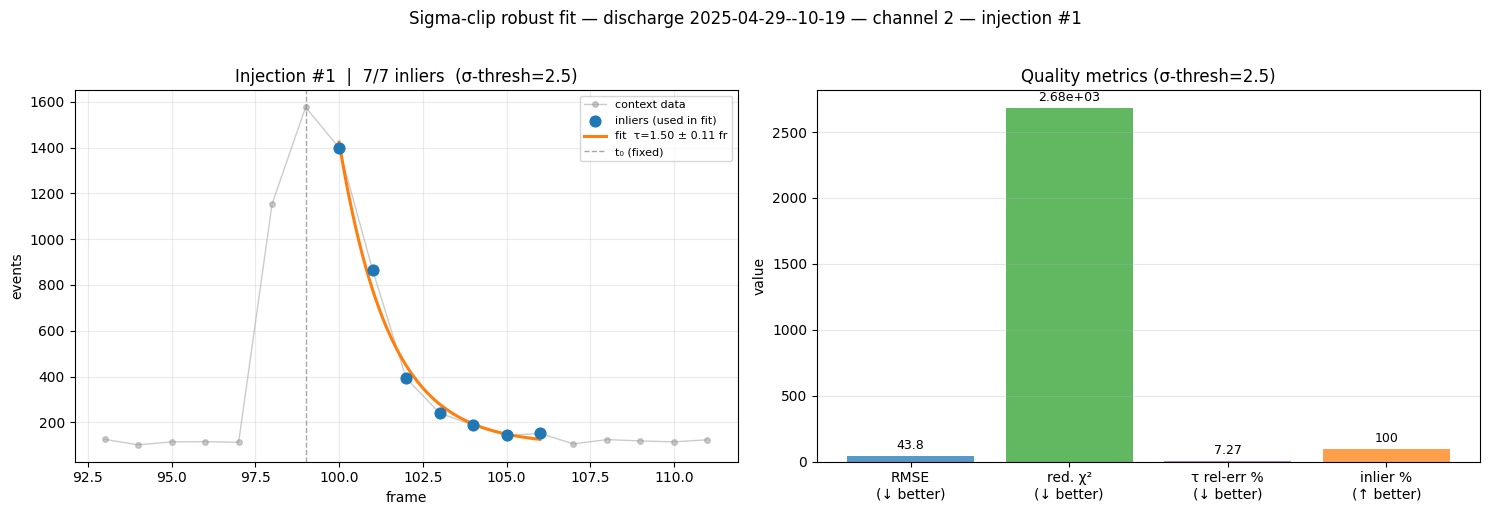

In [ ]:
"""Cell 5 — Visualization: show inliers/outliers and fit curve for injection #1 of a discharge 2025-04-29--10-19

Two panels:
  Left  — the injection region with inlier/outlier points colour-coded
           and the fitted curve drawn over ALL injection frames.
  Right — bar chart of the four quality metrics for sigma_thresh=2.5.
"""

if not result["success"]:
    print("No successful fit to plot.")
else:
    fn  = trace.frame_numbers
    v   = trace.values
    t_all      = result["t_all"]
    y_all      = result["y_all"]
    inlier_mask = result["inlier_mask"]

    A, tau, t_0, C_bg = result["A"], result["tau"], result["t_0"], result["C_bg"]

    # dense curve for plotting
    t_curve = np.linspace(float(t_all[0]), float(t_all[-1]), 300)
    y_curve = _exp_model(t_curve, A, tau, t_0, C_bg)

    # slightly wider context window
    ctx_lo = max(0, injection.start_frame - 5)
    ctx_hi = min(int(fn[-1]), injection.finish_frame + 5)
    ctx_mask = (fn >= ctx_lo) & (fn <= ctx_hi)

    fig, (ax_fit, ax_metrics) = plt.subplots(1, 2, figsize=(15, 5))

    # ---- left panel: fit + inlier/outlier annotation ----
    # background context (grey, faint)
    ax_fit.plot(fn[ctx_mask], v[ctx_mask], "o-", ms=4, lw=1,
                color="0.6", alpha=0.5, zorder=1, label="context data")

    # inliers (blue circles)
    ax_fit.scatter(t_all[inlier_mask], y_all[inlier_mask],
                   s=60, color="tab:blue", zorder=4, label="inliers (used in fit)")

    # outliers (red X)
    if (~inlier_mask).any():
        ax_fit.scatter(t_all[~inlier_mask], y_all[~inlier_mask],
                       s=80, marker="x", color="tab:red", linewidths=2,
                       zorder=5, label="outliers (sigma-clipped)")

    # fitted curve
    ax_fit.plot(t_curve, y_curve, color="tab:orange", lw=2.2, zorder=3,
                label=f"fit  τ={tau:.2f} ± {result['tau_err']:.2f} fr")

    ax_fit.axvline(injection.start_frame + 1, color="gray", ls="--", lw=1,
                   alpha=0.7, label="t₀ (fixed)")
    ax_fit.set_xlabel("frame")
    ax_fit.set_ylabel("events")
    ax_fit.set_title(f"Injection #{injection.injection_no}  |  "
                     f"{result['n_inliers']}/{result['n_total']} inliers  "
                     f"(σ-thresh=2.5)")
    ax_fit.legend(fontsize=8)
    ax_fit.grid(alpha=0.25)

    # ---- right panel: metric bar chart ----
    metric_names  = ["RMSE\n(↓ better)", "red. χ²\n(↓ better)",
                     "τ rel-err %\n(↓ better)", "inlier %\n(↑ better)"]
    metric_values = [
        result["rmse_inliers"],
        result["reduced_chi2"],
        result["tau_err_rel"] * 100,
        result["inlier_fraction"] * 100,
    ]
    colors = ["tab:blue", "tab:green", "tab:purple", "tab:orange"]
    bars = ax_metrics.bar(metric_names, metric_values, color=colors, alpha=0.75)
    for bar, val in zip(bars, metric_values):
        ax_metrics.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(metric_values) * 0.01,
                        f"{val:.3g}", ha="center", va="bottom", fontsize=9)
    ax_metrics.set_title("Quality metrics (σ-thresh=2.5)")
    ax_metrics.set_ylabel("value")
    ax_metrics.grid(axis="y", alpha=0.3)

    fig.suptitle(
        f"Sigma-clip robust fit — discharge 2025-04-29--10-19 — "
        f"channel {CHANNEL_ID} — injection #{injection.injection_no}",
        y=1.02, fontsize=12,
    )
    fig.tight_layout()
    plt.show()


Injection #1  span = frames 98..106
  Original t_0 (start_frame+1)    = frame 99
  Auto-detected t_0 (first fall)  = frame 100
  → t_0 shifted: measured peak is not at start_frame+1


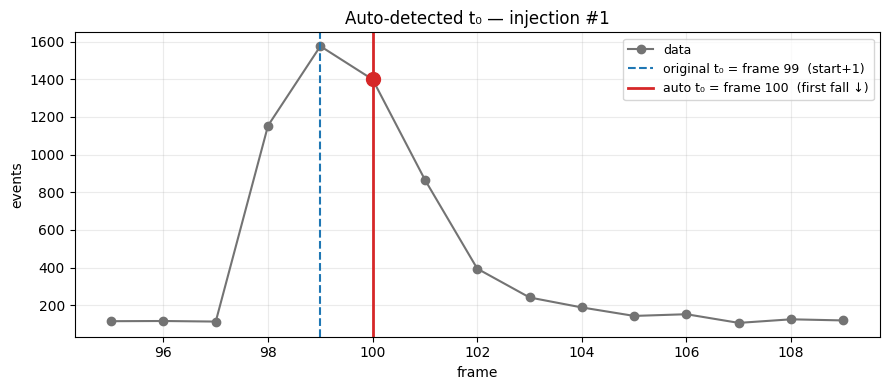

In [ ]:
"""Cell 7 — Demo: show where auto-detected t_0 lands vs original convention. for injection #1 of a discharge 2025-04-29--10-19"""

auto_t0_frame = find_first_falling_frame(trace, injection)
original_t0   = int(injection.start_frame + 1)

print(f"Injection #{injection.injection_no}  "
      f"span = frames {injection.start_frame}..{injection.finish_frame}")
print(f"  Original t_0 (start_frame+1)    = frame {original_t0}")
print(f"  Auto-detected t_0 (first fall)  = frame {auto_t0_frame}")
if auto_t0_frame != original_t0:
    print("  → t_0 shifted: measured peak is not at start_frame+1")
else:
    print("  → t_0 unchanged: decay starts right at the second burst point")

# --- plot: mark both t_0 candidates on the injection data ---
fn_   = trace.frame_numbers
v_    = trace.values
ctx_lo_ = max(0, injection.start_frame - 3)
ctx_hi_ = min(int(fn_[-1]), injection.finish_frame + 3)
ctx_  = (fn_ >= ctx_lo_) & (fn_ <= ctx_hi_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fn_[ctx_], v_[ctx_], "o-", ms=6, color="0.45", lw=1.5, label="data")
ax.axvline(original_t0,   color="tab:blue", ls="--", lw=1.5,
           label=f"original t₀ = frame {original_t0}  (start+1)")
ax.axvline(auto_t0_frame, color="tab:red",  ls="-",  lw=2,
           label=f"auto t₀ = frame {auto_t0_frame}  (first fall ↓)")
ax.scatter([auto_t0_frame], [v_[fn_ == auto_t0_frame][0]],
           s=100, zorder=5, color="tab:red")
ax.set_xlabel("frame")
ax.set_ylabel("events")
ax.set_title(f"Auto-detected t₀ — injection #{injection.injection_no}")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


NameError: name 'fit_sigma_clip' is not defined

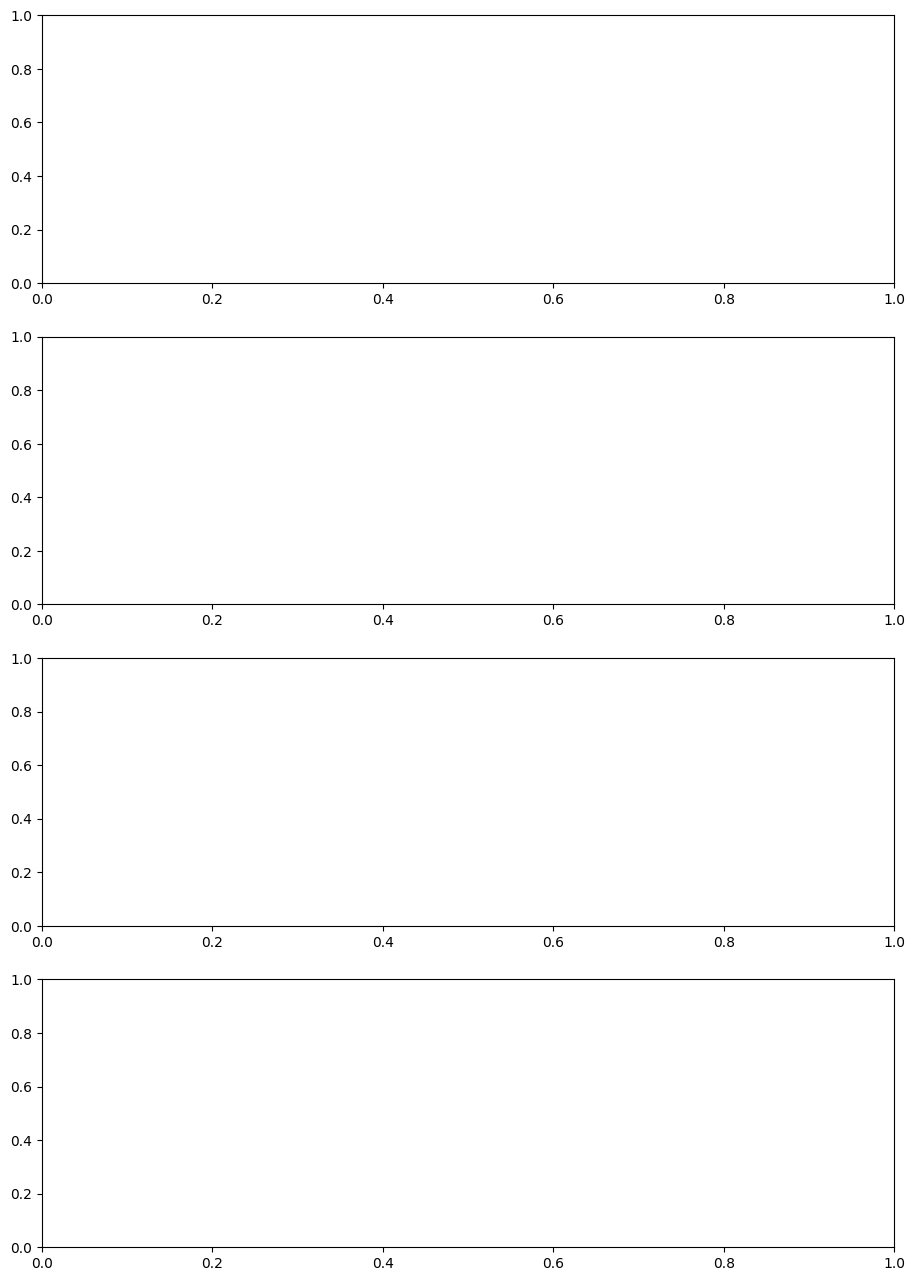

In [3]:
"""Cell 8 — Fit all injections and plot each one. discharge 2025-04-29--10-19"""

fn_ = trace.frame_numbers
v_  = trace.values

fig, axes = plt.subplots(
    len(injections), 1,
    figsize=(11, 4 * len(injections)),
    squeeze=False,
)

for ax, inj in zip(axes[:, 0], injections):
    r = fit_sigma_clip(trace, inj, sigma_thresh=2.5)

    # context window around the injection
    ctx_lo = max(0, inj.start_frame - 4)
    ctx_hi = min(int(fn_[-1]), inj.finish_frame + 4)
    ctx    = (fn_ >= ctx_lo) & (fn_ <= ctx_hi)

    # faint full context
    ax.plot(fn_[ctx], v_[ctx], "o-", ms=4, lw=1, color="0.6", alpha=0.5,
            label="context data")

    if r["success"]:
        t_all       = r["t_all"]
        y_all       = r["y_all"]
        inlier_mask = r["inlier_mask"]
        A, tau, t_0, C_bg = r["A"], r["tau"], r["t_0"], r["C_bg"]

        # inliers and outliers
        ax.scatter(t_all[inlier_mask], y_all[inlier_mask],
                   s=55, color="tab:blue", zorder=4, label="inliers")
        if (~inlier_mask).any():
            ax.scatter(t_all[~inlier_mask], y_all[~inlier_mask],
                       s=70, marker="x", color="tab:red", linewidths=2,
                       zorder=5, label="sigma-clipped")

        # fitted curve over the decay span
        t_curve = np.linspace(float(t_all[0]), float(t_all[-1]), 300)
        y_curve = _exp_model(t_curve, A, tau, t_0, C_bg)
        ax.plot(t_curve, y_curve, color="tab:orange", lw=2.2, zorder=3,
                label=f"fit  τ={tau:.2f}±{r['tau_err']:.2f} fr  "
                      f"(τ_rel={r['tau_err_rel']*100:.1f}%,  "
                      f"inliers={r['n_inliers']}/{r['n_total']})")

        # mark auto-detected t_0
        ax.axvline(t_0, color="tab:red", ls="-", lw=1.3, alpha=0.7,
                   label=f"auto t₀={int(t_0)}")
    else:
        # show failure message in title
        ax.text(0.5, 0.5, f"fit failed: {r['message']}",
                transform=ax.transAxes, ha="center", va="center",
                color="red", fontsize=10)

    ax.set_title(f"Injection #{inj.injection_no}  "
                 f"(frames {inj.start_frame}–{inj.finish_frame})")
    ax.set_xlabel("frame")
    ax.set_ylabel("events")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(
    f"All injections — discharge 2025-04-29--10-19 — channel {CHANNEL_ID}",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()


In [5]:
"""importing test discharge folder"""
TEST_DIR = ROOT / "data" / "discharges" / "test"

# load test discharge and build trace
test_discharge  = io.load_test_folder(TEST_DIR, discharge_id="test")
test_channel    = test_discharge.channels[CHANNEL_ID]
test_trace      = integrate_energy_window(test_channel, LINE_E, HALF_W)
test_injections = detect_injections(test_trace, LINE_E)

print(f"Loaded: {test_discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(test_injections)} injection(s) detected")
for inj in test_injections:
    print(f"  #{inj.injection_no}  frames {inj.start_frame}..{inj.finish_frame}  "
          f"(span={inj.finish_frame - inj.start_frame})")

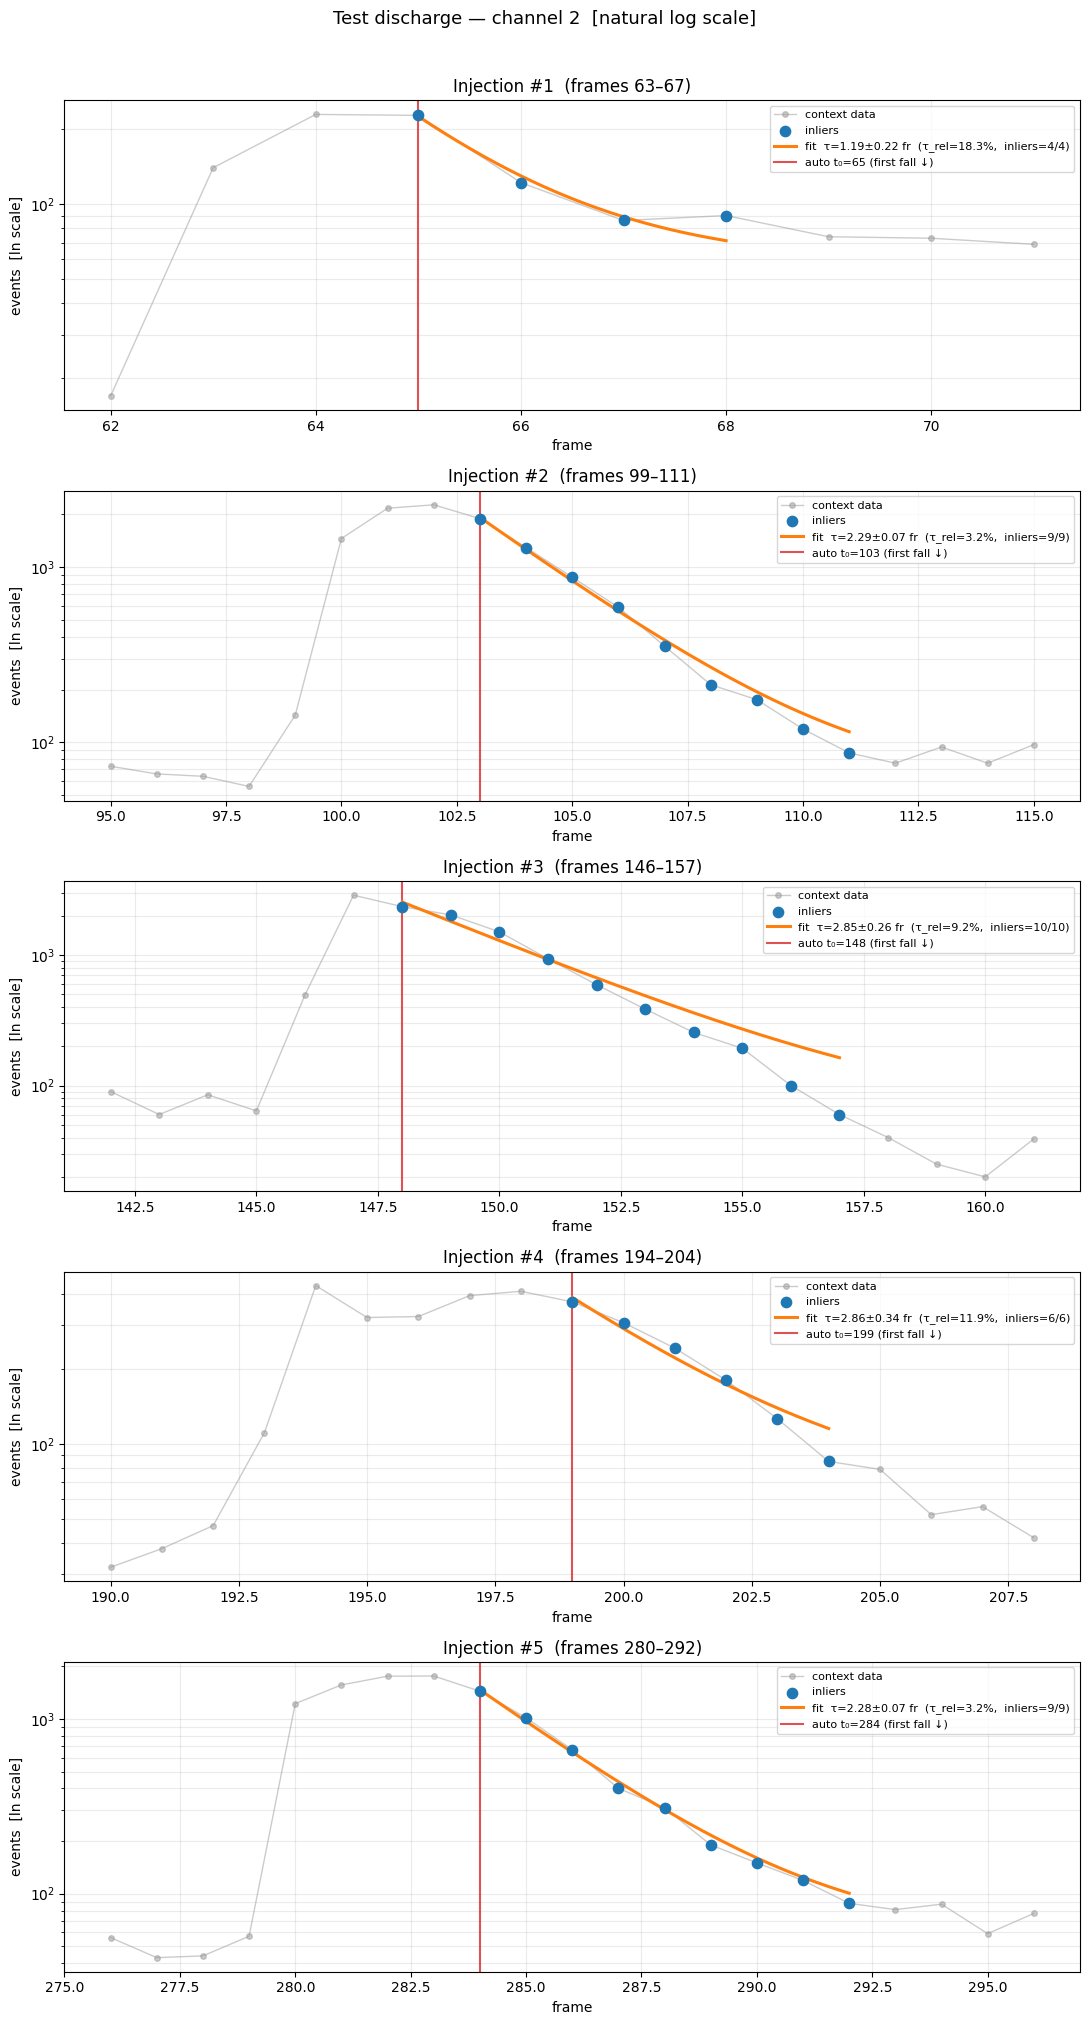

In [11]:
"""Cell 9 — Load test discharge, fit all injections, plot each one (log scale). discharge test"""


if not test_injections:
    print("No injections detected — nothing to plot.")
else:
    t_fn = test_trace.frame_numbers
    t_v  = test_trace.values

    fig, axes = plt.subplots(
        len(test_injections), 1,
        figsize=(11, 4 * len(test_injections)),
        squeeze=False,
    )

    for ax, inj in zip(axes[:, 0], test_injections):
        r = fit_sigma_clip(test_trace, inj, sigma_thresh=2.5)

        # auto-detected t_0 for this injection
        auto_t0 = find_first_falling_frame(test_trace, inj)

        # context window around the injection
        ctx_lo = max(0, inj.start_frame - 4)
        ctx_hi = min(int(t_fn[-1]), inj.finish_frame + 4)
        ctx    = (t_fn >= ctx_lo) & (t_fn <= ctx_hi)

        # clip context values to be > 0 so log scale works
        ctx_v_safe = np.where(t_v[ctx] > 0, t_v[ctx], np.nan)

        # faint context data
        ax.plot(t_fn[ctx], ctx_v_safe, "o-", ms=4, lw=1, color="0.6",
                alpha=0.5, label="context data")

        if r["success"]:
            t_all_r       = r["t_all"]
            y_all_r       = r["y_all"]
            inlier_mask_r = r["inlier_mask"]
            A_r, tau_r, t0_r, Cbg_r = r["A"], r["tau"], r["t_0"], r["C_bg"]

            # inliers (blue) and sigma-clipped outliers (red X)
            # clip to > 0 before log plotting
            y_inliers = np.where(y_all_r[inlier_mask_r] > 0,
                                 y_all_r[inlier_mask_r], np.nan)
            ax.scatter(t_all_r[inlier_mask_r], y_inliers,
                       s=55, color="tab:blue", zorder=4, label="inliers")

            if (~inlier_mask_r).any():
                y_out = np.where(y_all_r[~inlier_mask_r] > 0,
                                 y_all_r[~inlier_mask_r], np.nan)
                ax.scatter(t_all_r[~inlier_mask_r], y_out,
                           s=70, marker="x", color="tab:red", linewidths=2,
                           zorder=5, label="sigma-clipped")

            # fitted exponential curve — on log scale a pure exp is a straight line
            t_curve_r = np.linspace(float(t_all_r[0]), float(t_all_r[-1]), 300)
            y_curve_r = _exp_model(t_curve_r, A_r, tau_r, t0_r, Cbg_r)
            ax.plot(t_curve_r, np.where(y_curve_r > 0, y_curve_r, np.nan),
                    color="tab:orange", lw=2.2, zorder=3,
                    label=f"fit  τ={tau_r:.2f}±{r['tau_err']:.2f} fr  "
                          f"(τ_rel={r['tau_err_rel']*100:.1f}%,  "
                          f"inliers={r['n_inliers']}/{r['n_total']})")

        # mark auto-detected t_0 from find_first_falling_frame
        ax.axvline(auto_t0, color="tab:red", ls="-", lw=1.5, alpha=0.8,
                   label=f"auto t₀={auto_t0} (first fall ↓)")

        # natural log scale on y-axis
        ax.set_yscale("log")

        ax.set_title(f"Injection #{inj.injection_no}  "
                     f"(frames {inj.start_frame}–{inj.finish_frame})")
        ax.set_xlabel("frame")
        ax.set_ylabel("events  [ln scale]")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25, which="both")

    fig.suptitle(
        f"Test discharge — channel {CHANNEL_ID}  [natural log scale]",
        fontsize=13, y=1.01,
    )
    fig.tight_layout()
    plt.show()


# Sweep sigma_thresh

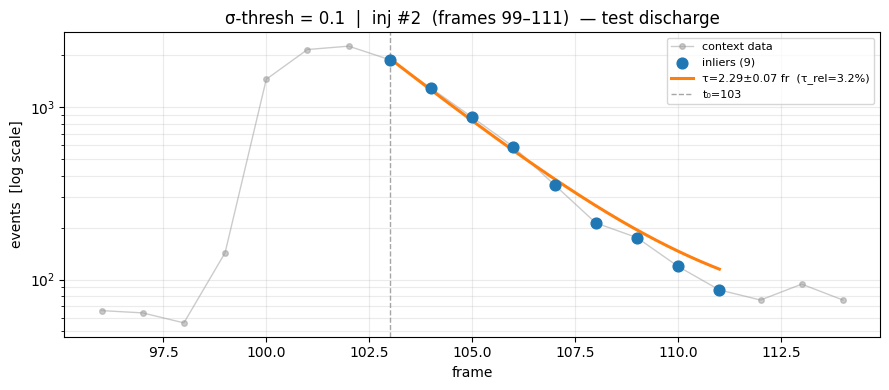

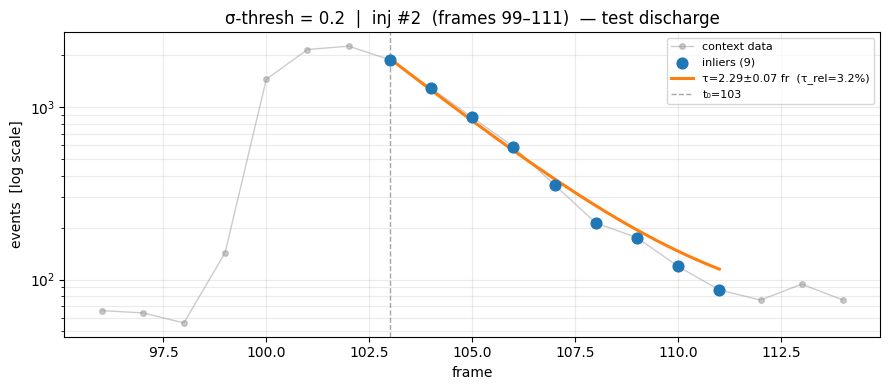

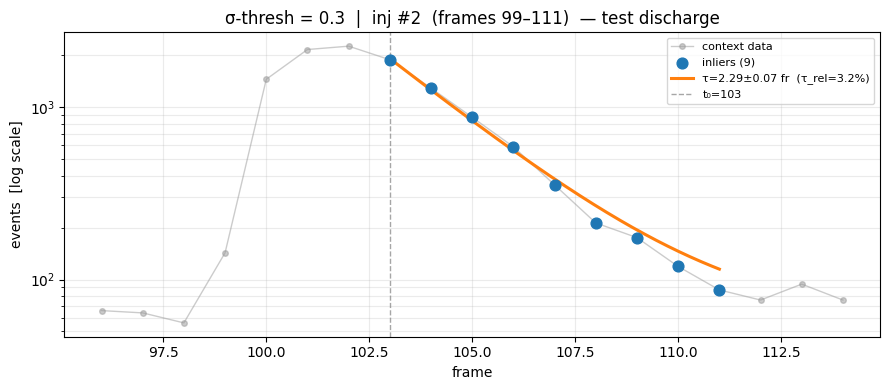

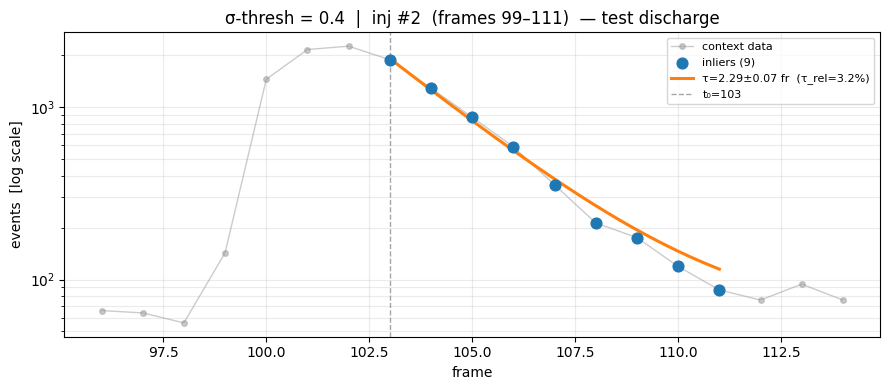

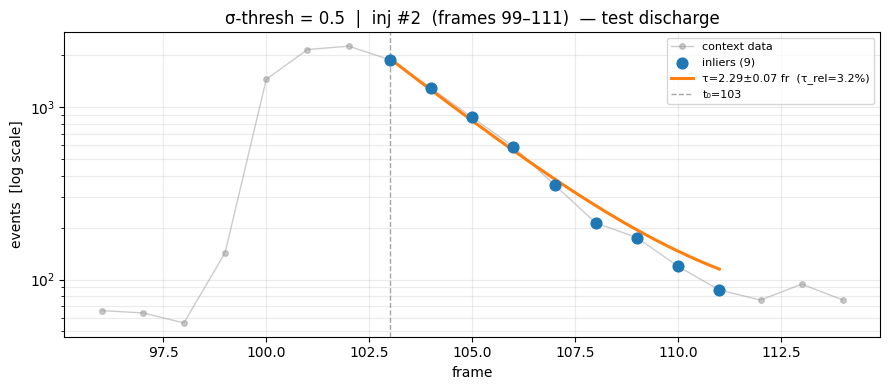

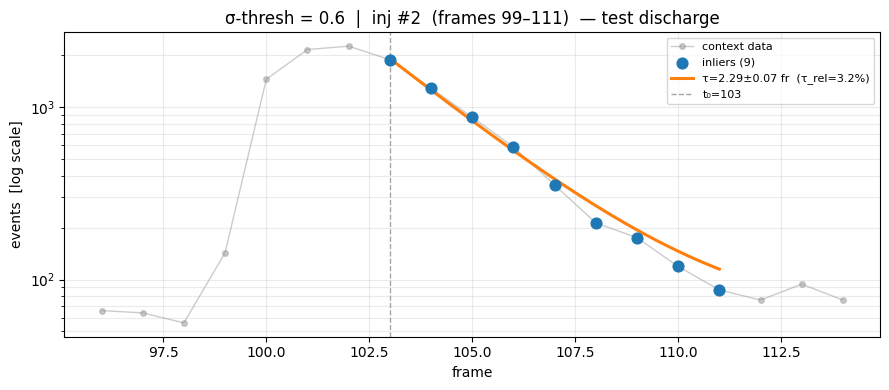

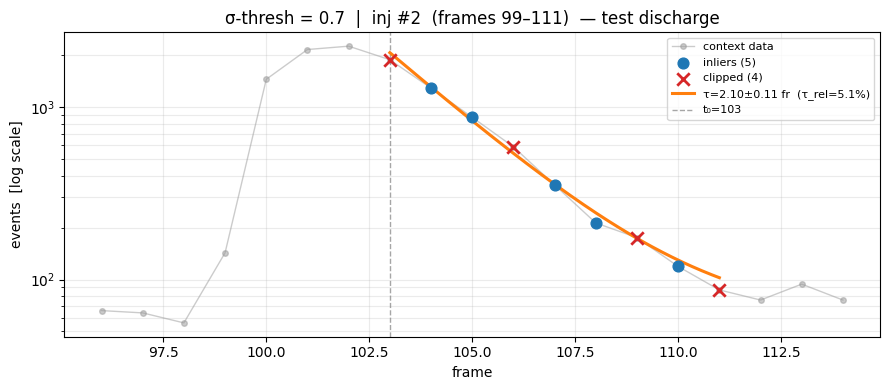

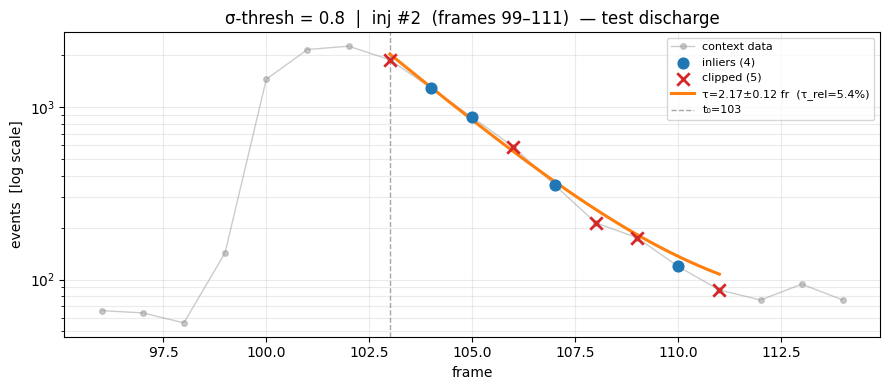

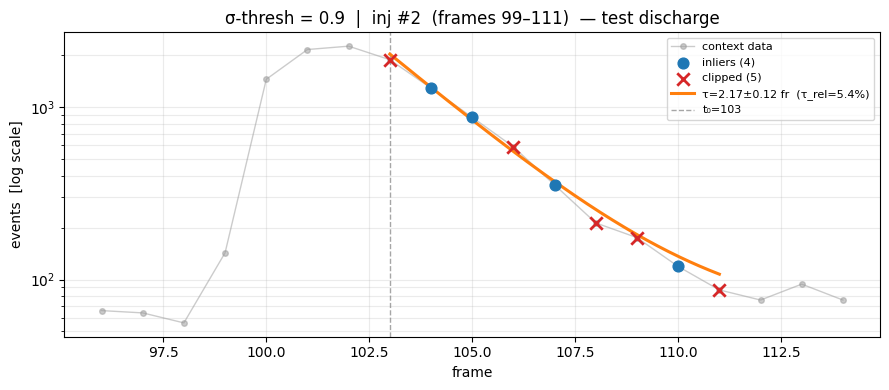

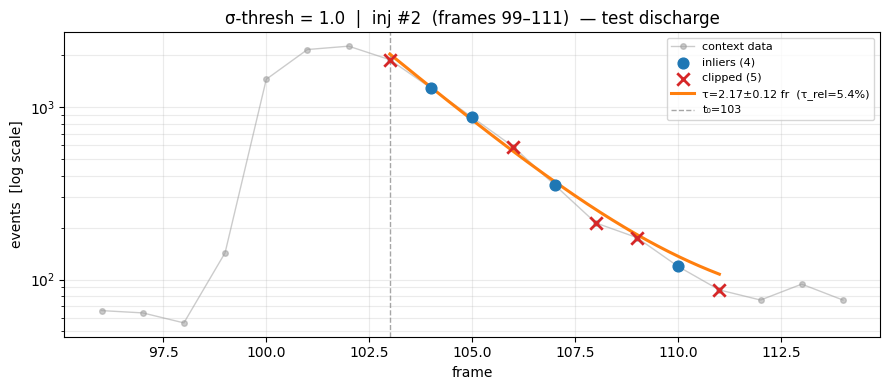

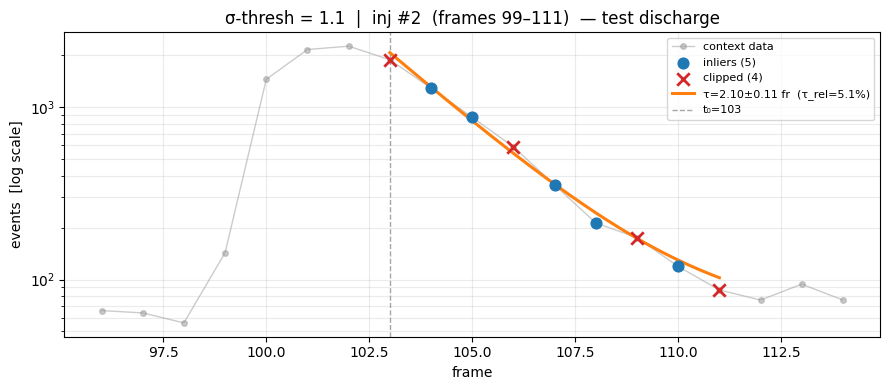

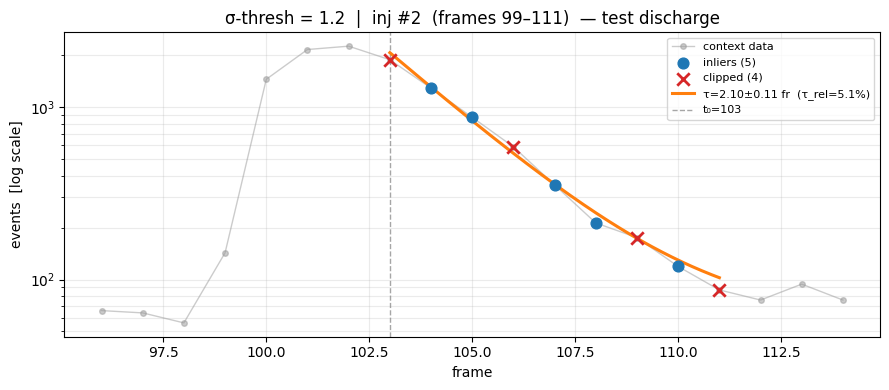

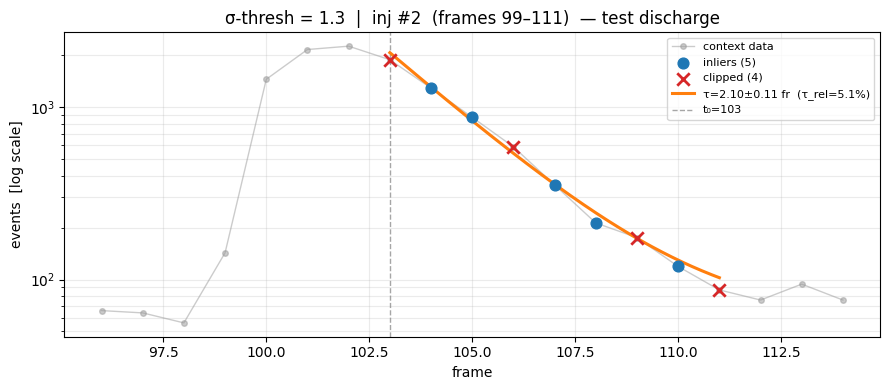

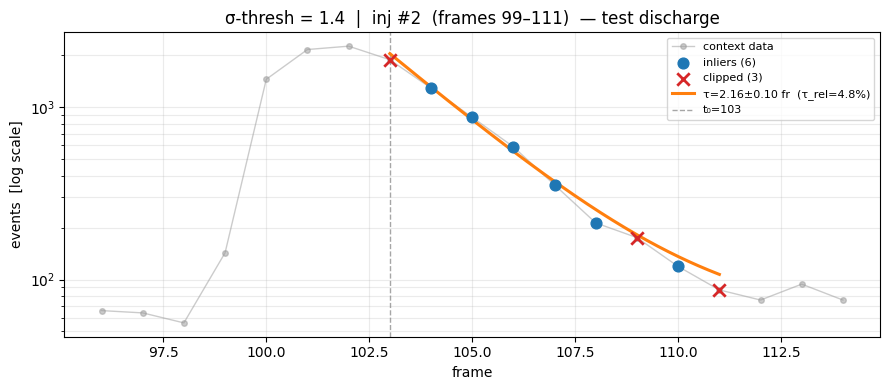

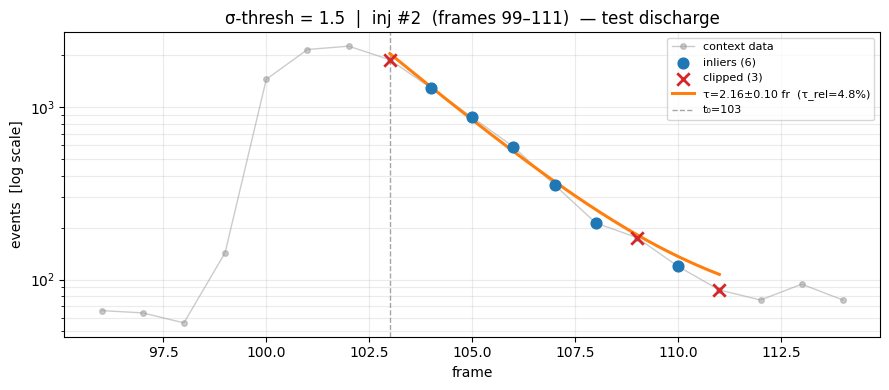

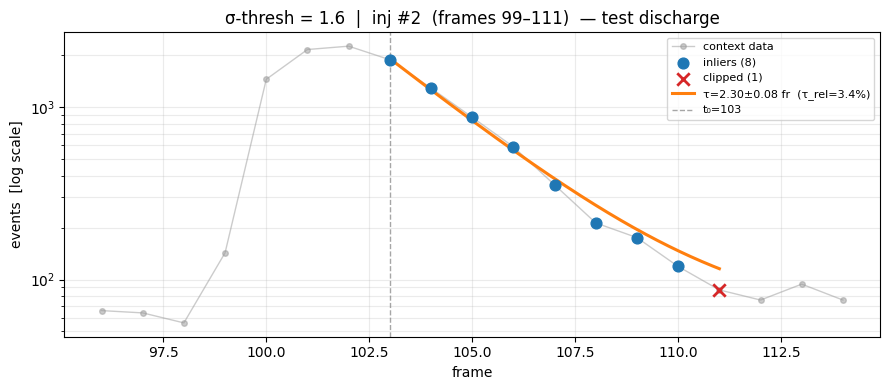

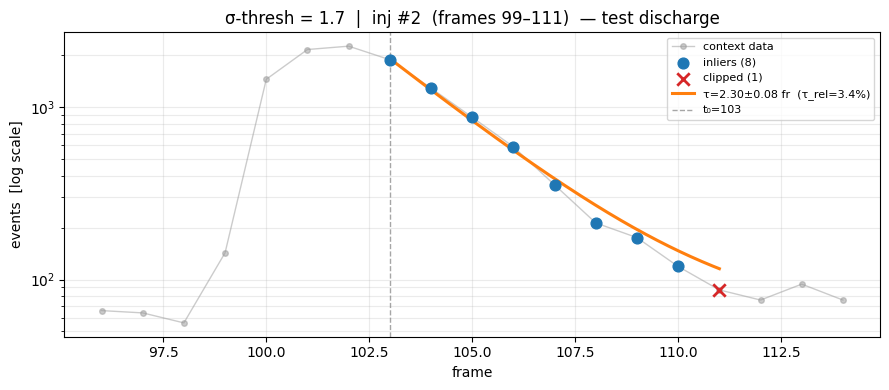

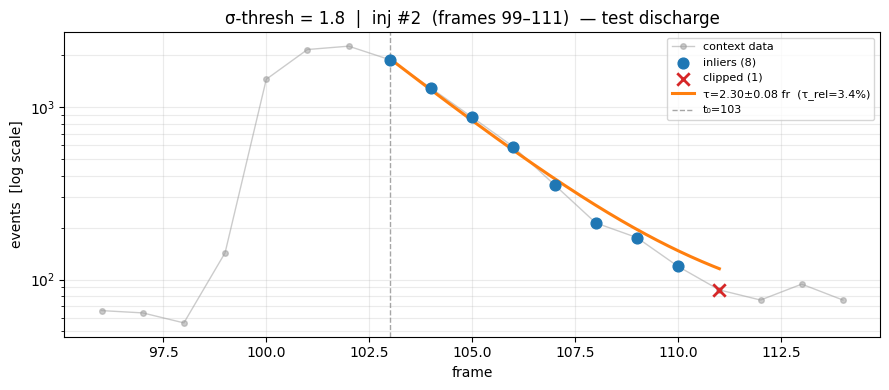

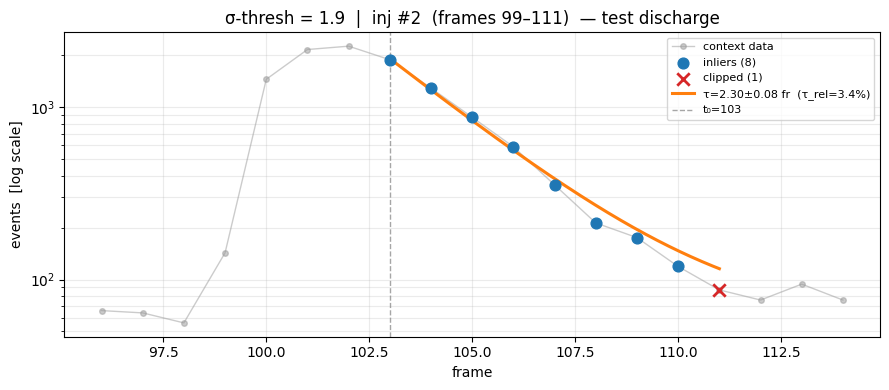

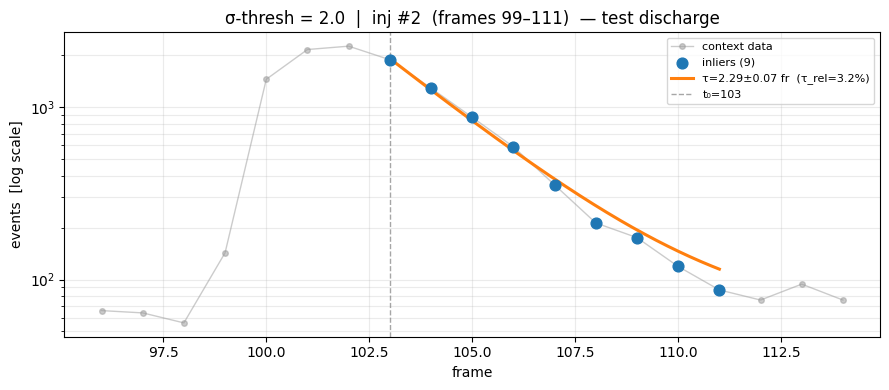

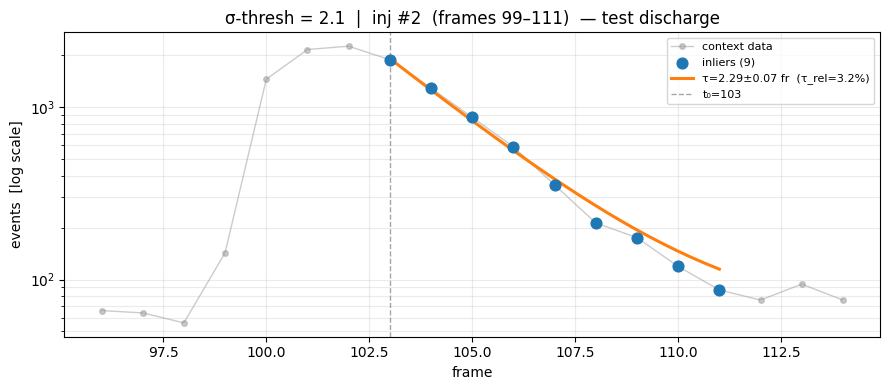

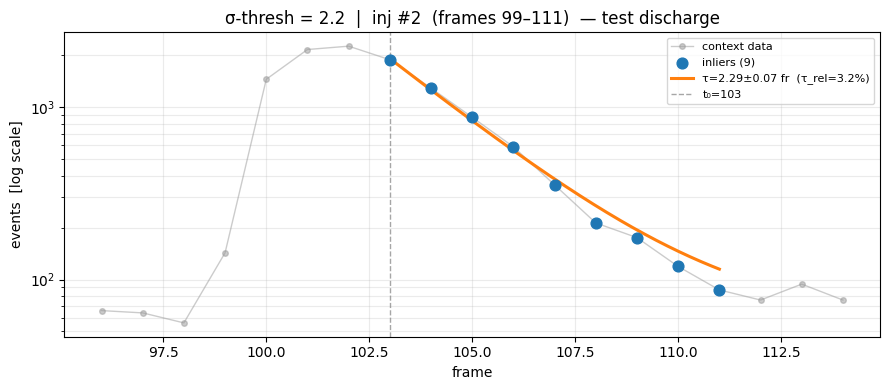

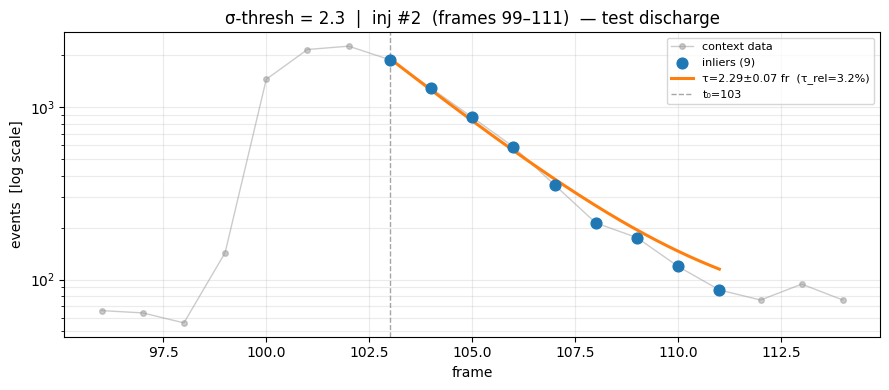

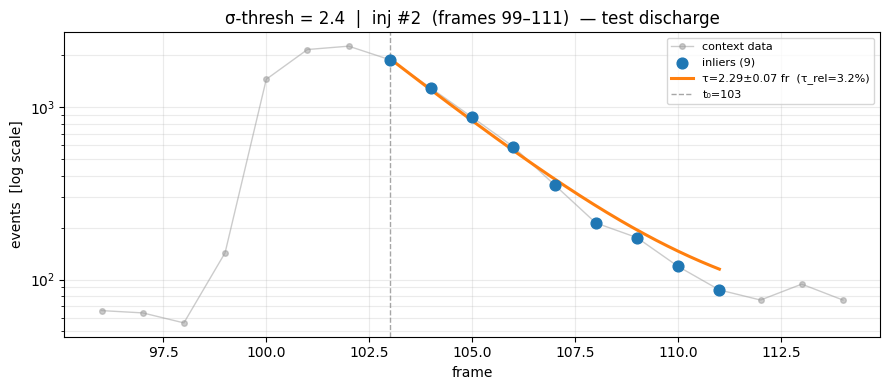

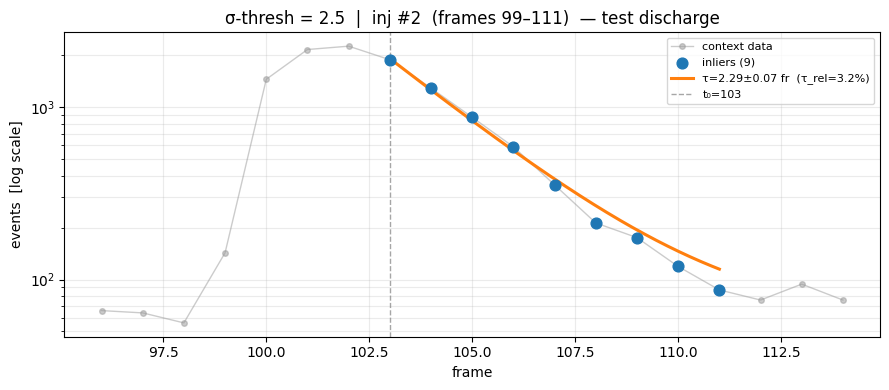

In [14]:
"""Sweep sigma_thresh on injection #2 of the TEST discharge.

One separate plot per threshold value, showing inliers/outliers and the fit curve.
"""

# --- pick injection #2 of the test discharge (index 1) ---
inj2_test = test_injections[1]

thresholds = np.round(np.arange(0.1, 2.51, 0.1), 2)

t_fn = test_trace.frame_numbers
t_v  = test_trace.values

# context window for all plots
ctx_lo = max(0, inj2_test.start_frame - 3)
ctx_hi = min(int(t_fn[-1]), inj2_test.finish_frame + 3)
ctx    = (t_fn >= ctx_lo) & (t_fn <= ctx_hi)

for th in thresholds:
    r = fit_sigma_clip(test_trace, inj2_test, sigma_thresh=th)

    fig, ax = plt.subplots(figsize=(9, 4))

    # faint context data
    ctx_v_safe = np.where(t_v[ctx] > 0, t_v[ctx], np.nan)
    ax.plot(t_fn[ctx], ctx_v_safe, "o-", ms=4, lw=1, color="0.6",
            alpha=0.5, label="context data")

    if r["success"]:
        t_a = r["t_all"]
        y_a = r["y_all"]
        im  = r["inlier_mask"]

        # inliers (blue) and sigma-clipped (red X)
        ax.scatter(t_a[im], y_a[im], s=60, color="tab:blue",
                   zorder=4, label=f"inliers ({im.sum()})")
        if (~im).any():
            ax.scatter(t_a[~im], y_a[~im], s=80, marker="x",
                       color="tab:red", linewidths=2, zorder=5,
                       label=f"clipped ({(~im).sum()})")

        # fitted curve
        t_c = np.linspace(float(t_a[0]), float(t_a[-1]), 300)
        y_c = _exp_model(t_c, r["A"], r["tau"], r["t_0"], r["C_bg"])
        ax.plot(t_c, np.where(y_c > 0, y_c, np.nan),
                color="tab:orange", lw=2.2, zorder=3,
                label=f"τ={r['tau']:.2f}±{r['tau_err']:.2f} fr  "
                      f"(τ_rel={r['tau_err_rel']*100:.1f}%)")

        ax.axvline(r["t_0"], color="gray", ls="--", lw=1, alpha=0.7,
                   label=f"t₀={int(r['t_0'])}")
    else:
        ax.text(0.5, 0.5, f"failed: {r['message']}",
                transform=ax.transAxes, ha="center", color="red", fontsize=10)

    ax.set_yscale("log")
    ax.set_xlabel("frame")
    ax.set_ylabel("events  [log scale]")
    ax.set_title(f"σ-thresh = {th:.1f}  |  inj #{inj2_test.injection_no}  "
                 f"(frames {inj2_test.start_frame}–{inj2_test.finish_frame})  "
                 f"— test discharge")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25, which="both")
    fig.tight_layout()
    plt.show()


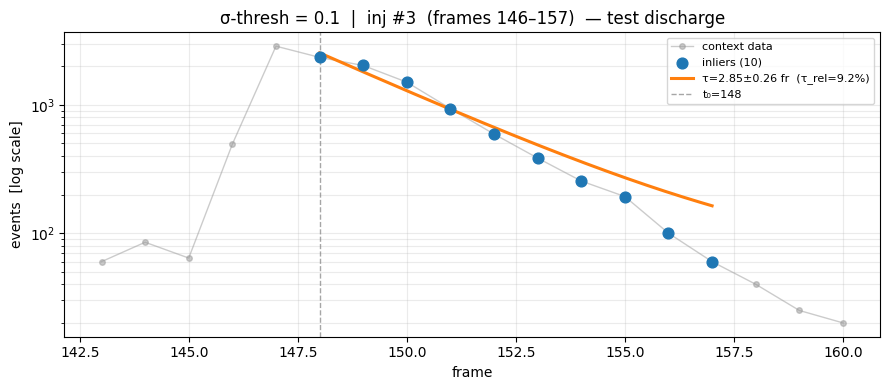

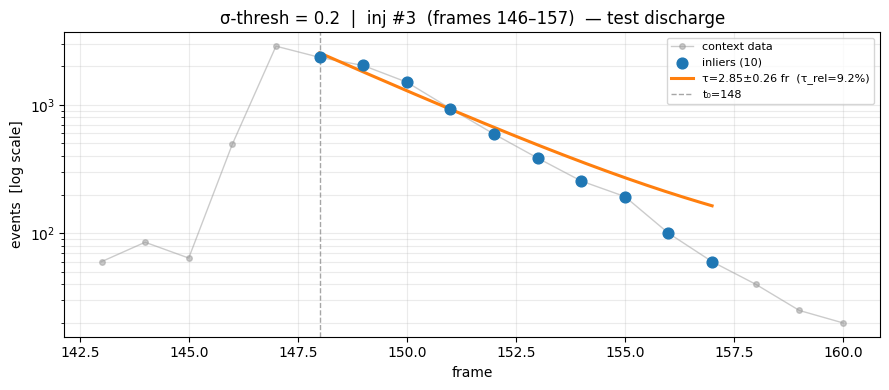

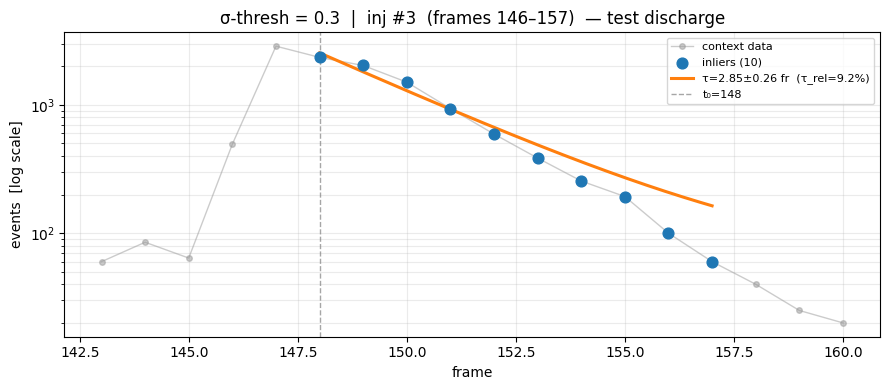

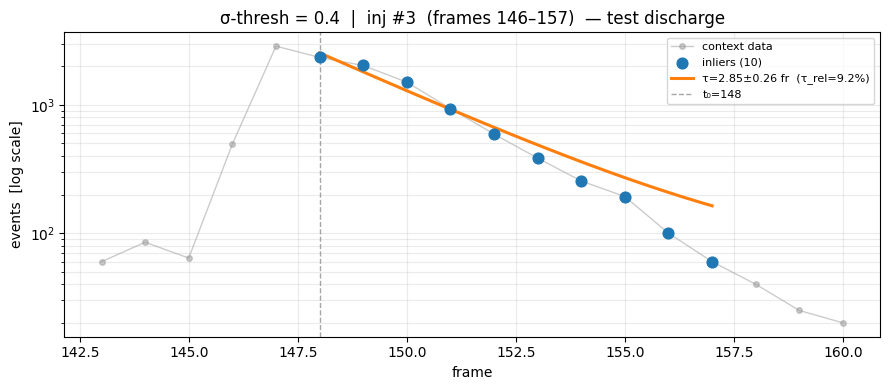

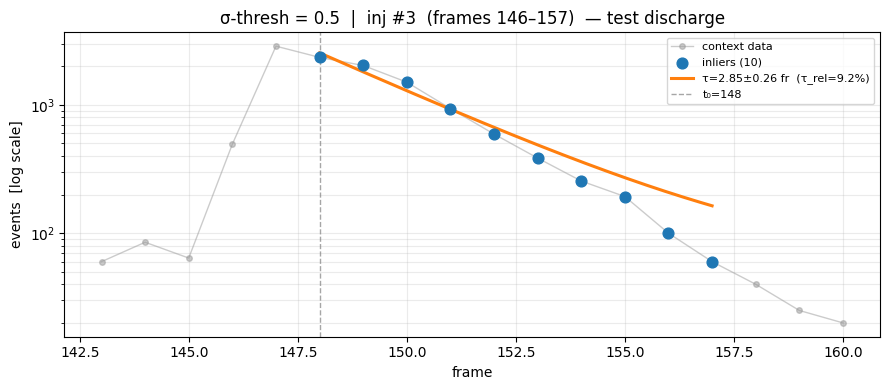

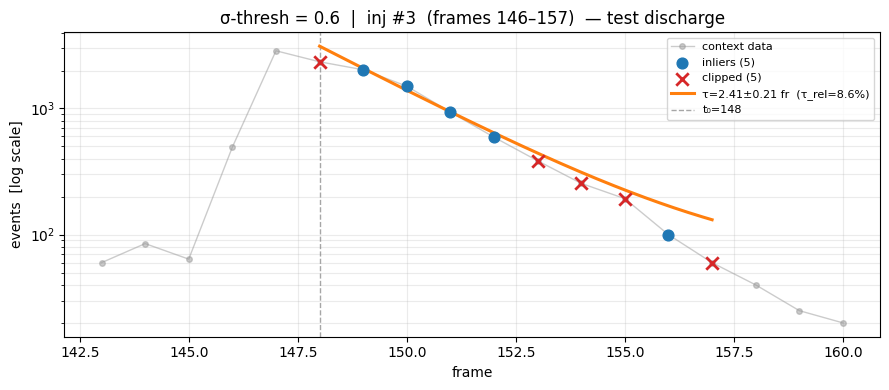

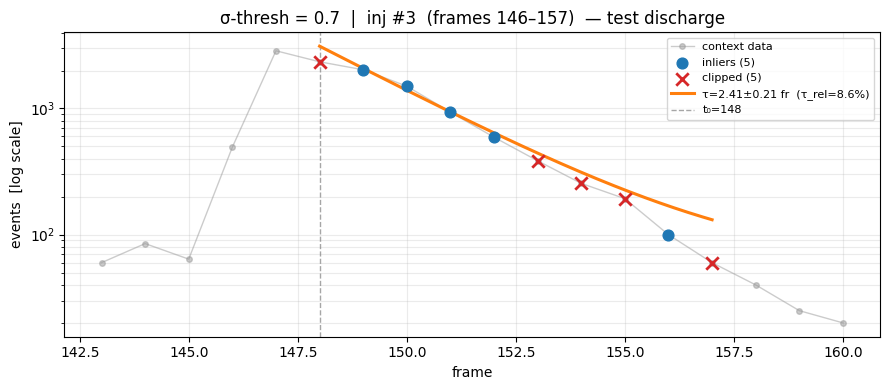

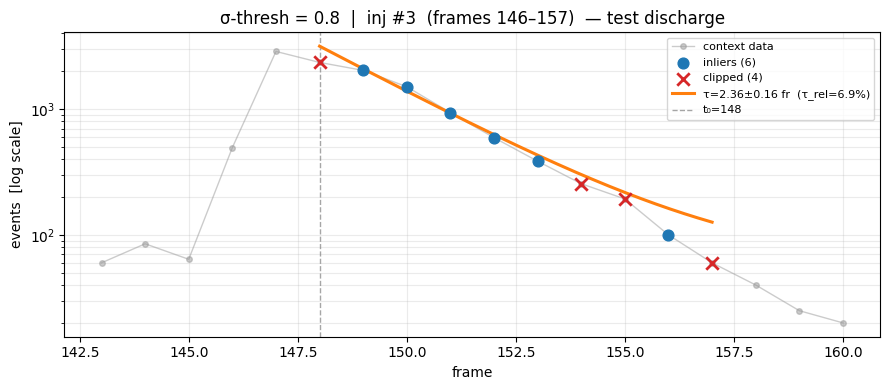

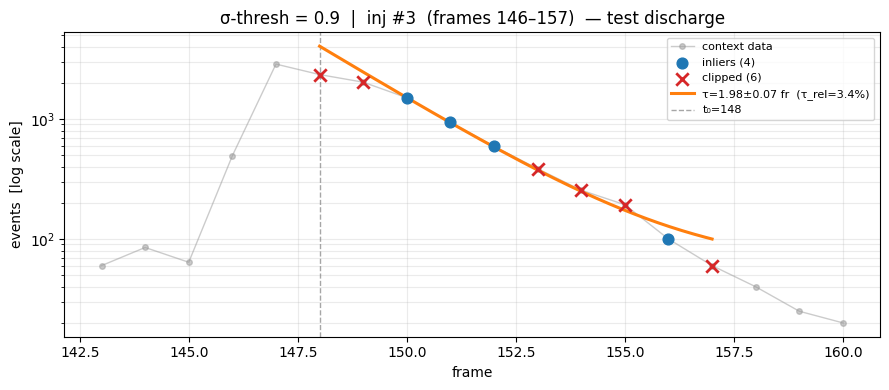

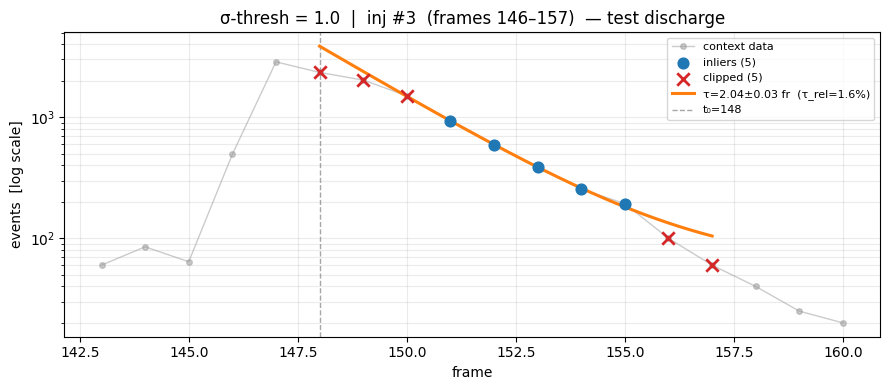

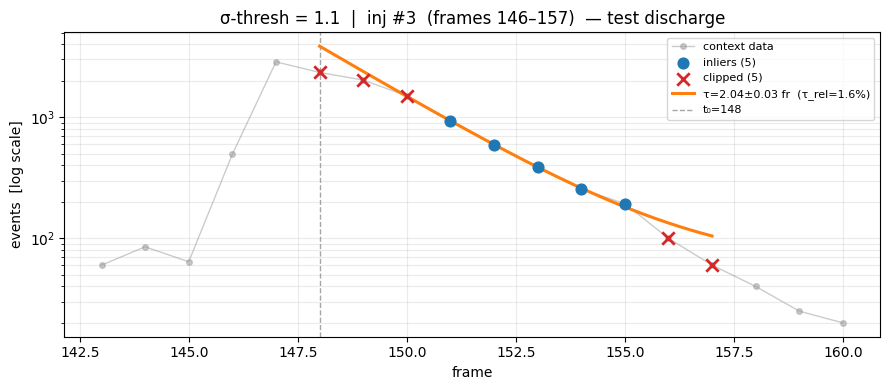

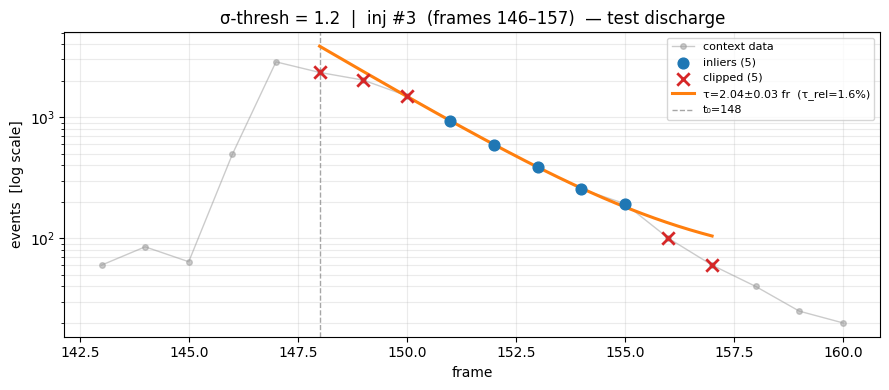

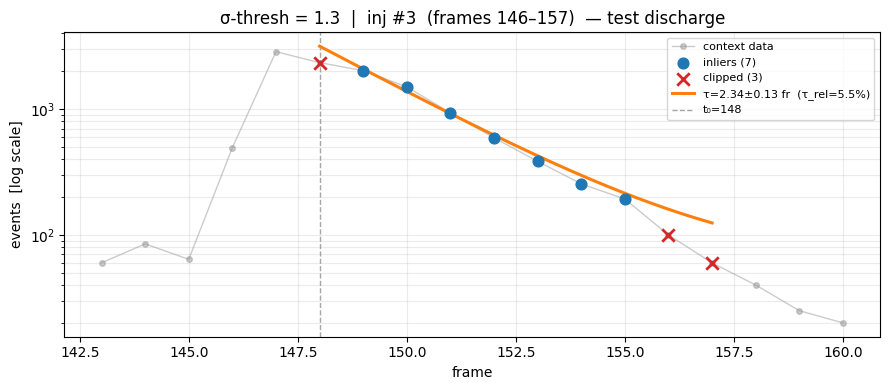

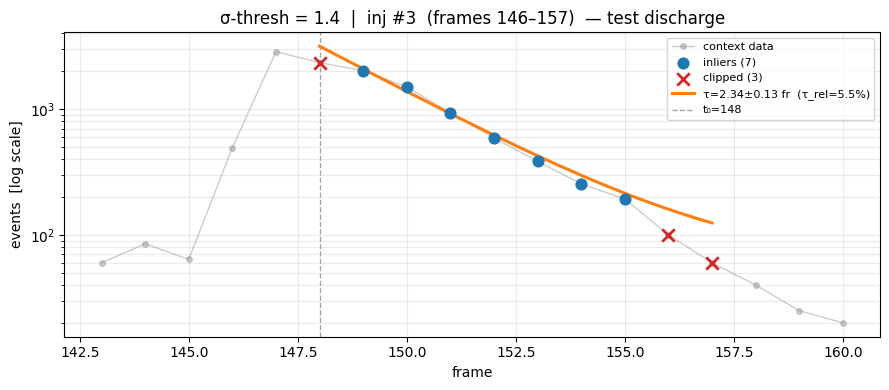

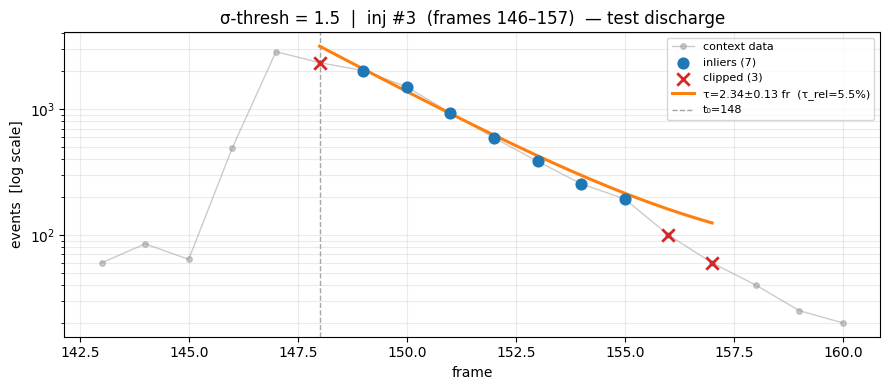

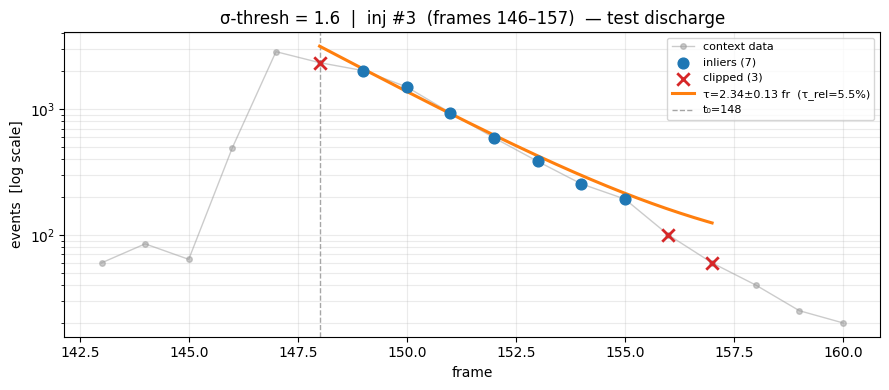

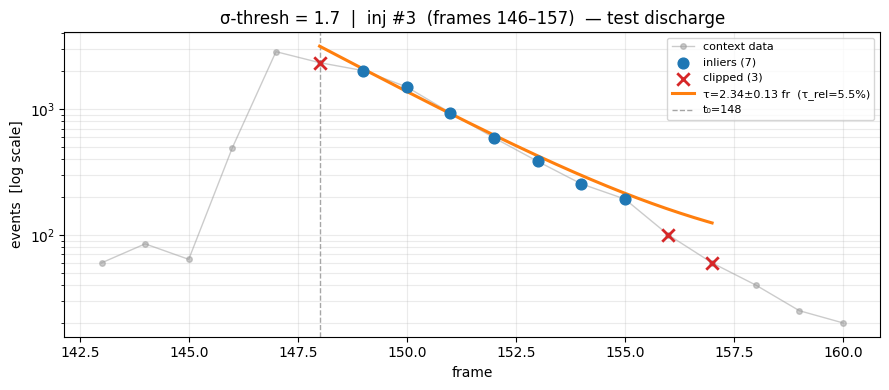

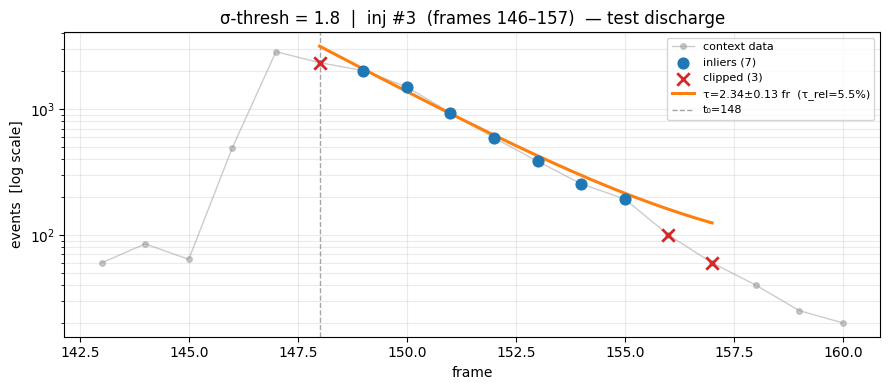

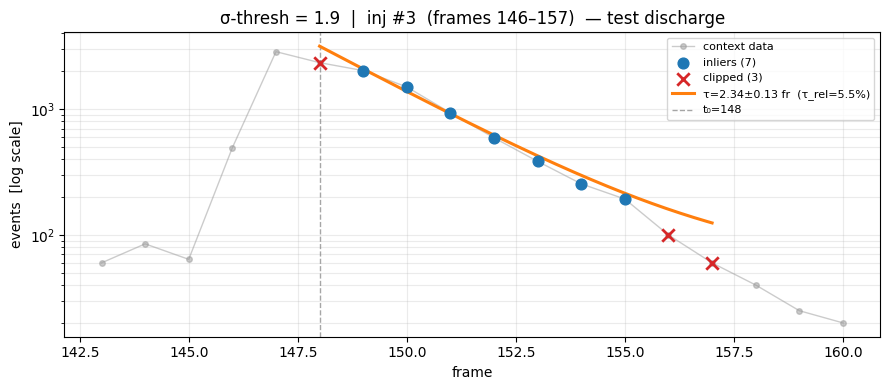

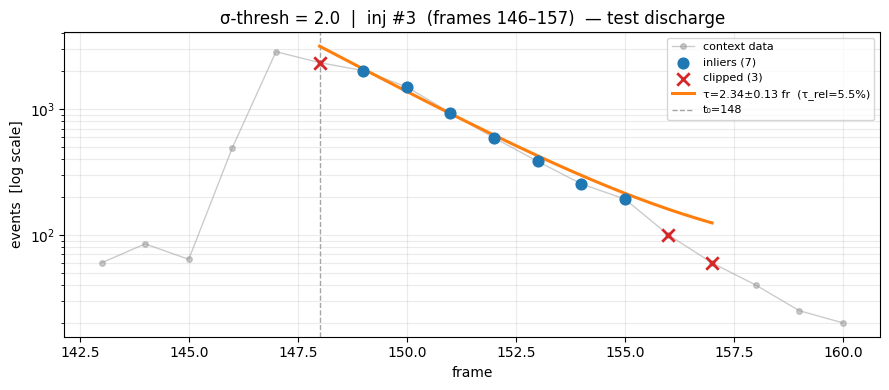

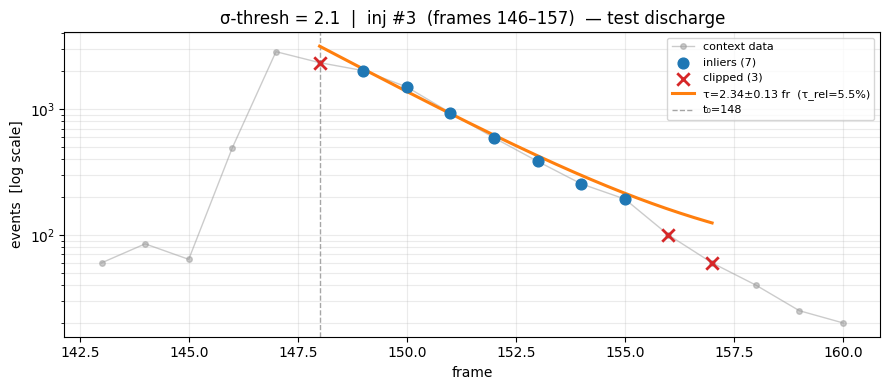

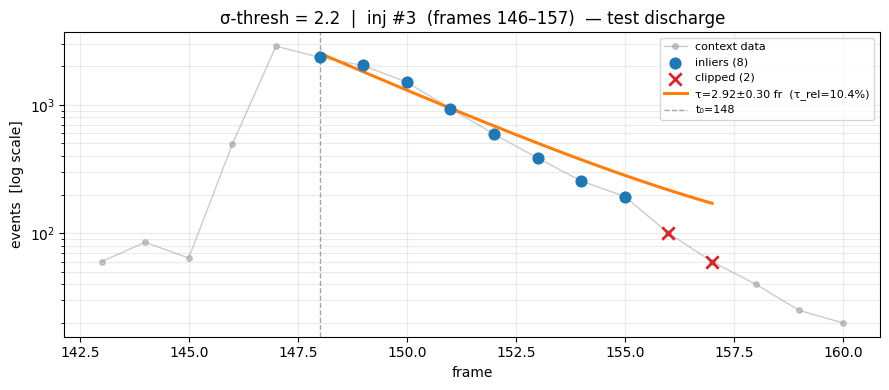

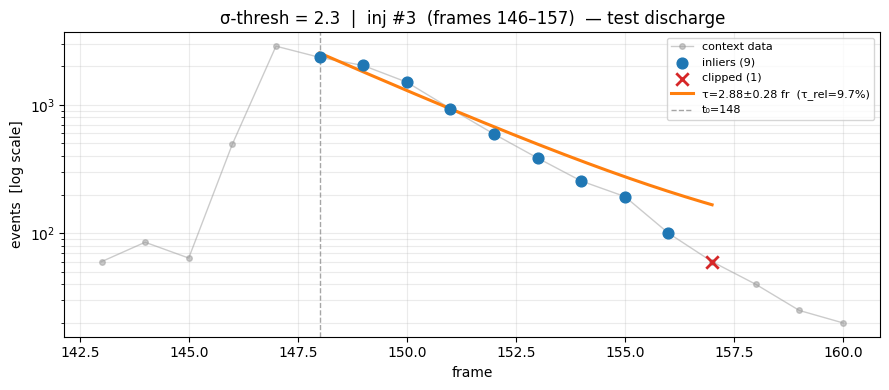

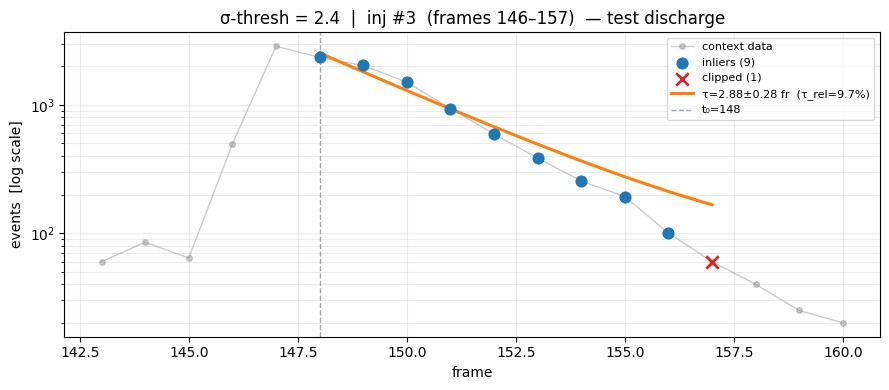

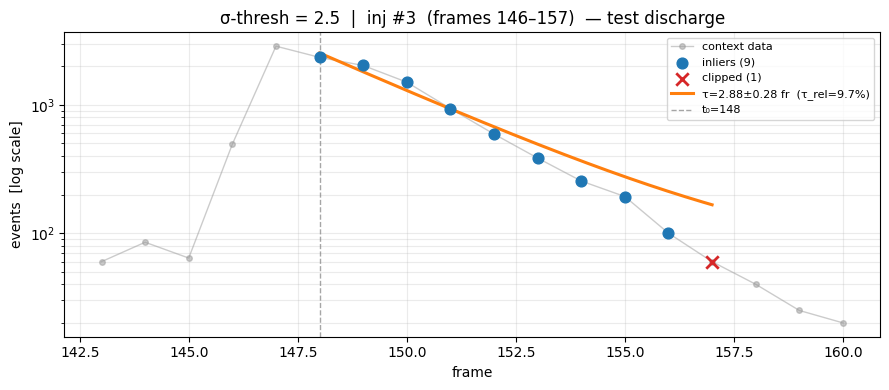

In [15]:
"""Sweep sigma_thresh on injection #3 of the TEST discharge.

Same as the injection #2 sweep — one plot per threshold.
"""

# --- pick injection #3 (index 2) ---
inj3_test = test_injections[2]

thresholds = np.round(np.arange(0.1, 2.51, 0.1), 2)

t_fn = test_trace.frame_numbers
t_v  = test_trace.values

# context window for all plots
ctx_lo = max(0, inj3_test.start_frame - 3)
ctx_hi = min(int(t_fn[-1]), inj3_test.finish_frame + 3)
ctx    = (t_fn >= ctx_lo) & (t_fn <= ctx_hi)

for th in thresholds:
    r = fit_sigma_clip(test_trace, inj3_test, sigma_thresh=th)

    fig, ax = plt.subplots(figsize=(9, 4))

    # faint context data
    ctx_v_safe = np.where(t_v[ctx] > 0, t_v[ctx], np.nan)
    ax.plot(t_fn[ctx], ctx_v_safe, "o-", ms=4, lw=1, color="0.6",
            alpha=0.5, label="context data")

    if r["success"]:
        t_a = r["t_all"]
        y_a = r["y_all"]
        im  = r["inlier_mask"]

        # inliers (blue) and sigma-clipped (red X)
        ax.scatter(t_a[im], y_a[im], s=60, color="tab:blue",
                   zorder=4, label=f"inliers ({im.sum()})")
        if (~im).any():
            ax.scatter(t_a[~im], y_a[~im], s=80, marker="x",
                       color="tab:red", linewidths=2, zorder=5,
                       label=f"clipped ({(~im).sum()})")

        # fitted curve
        t_c = np.linspace(float(t_a[0]), float(t_a[-1]), 300)
        y_c = _exp_model(t_c, r["A"], r["tau"], r["t_0"], r["C_bg"])
        ax.plot(t_c, np.where(y_c > 0, y_c, np.nan),
                color="tab:orange", lw=2.2, zorder=3,
                label=f"τ={r['tau']:.2f}±{r['tau_err']:.2f} fr  "
                      f"(τ_rel={r['tau_err_rel']*100:.1f}%)")

        ax.axvline(r["t_0"], color="gray", ls="--", lw=1, alpha=0.7,
                   label=f"t₀={int(r['t_0'])}")
    else:
        ax.text(0.5, 0.5, f"failed: {r['message']}",
                transform=ax.transAxes, ha="center", color="red", fontsize=10)

    ax.set_yscale("log")
    ax.set_xlabel("frame")
    ax.set_ylabel("events  [log scale]")
    ax.set_title(f"σ-thresh = {th:.1f}  |  inj #{inj3_test.injection_no}  "
                 f"(frames {inj3_test.start_frame}–{inj3_test.finish_frame})  "
                 f"— test discharge")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25, which="both")
    fig.tight_layout()
    plt.show()


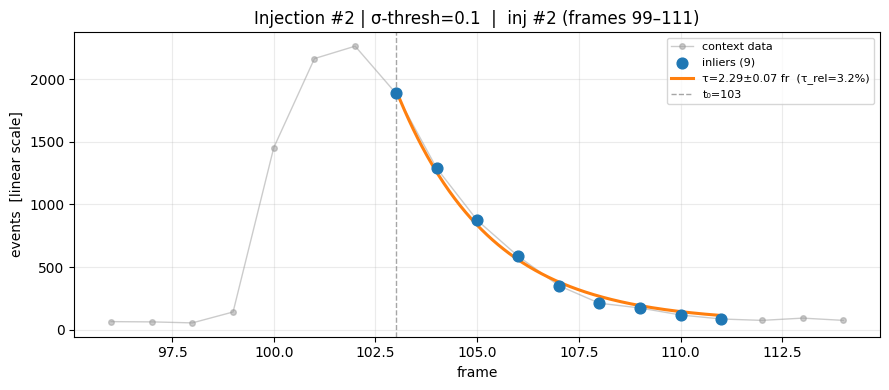

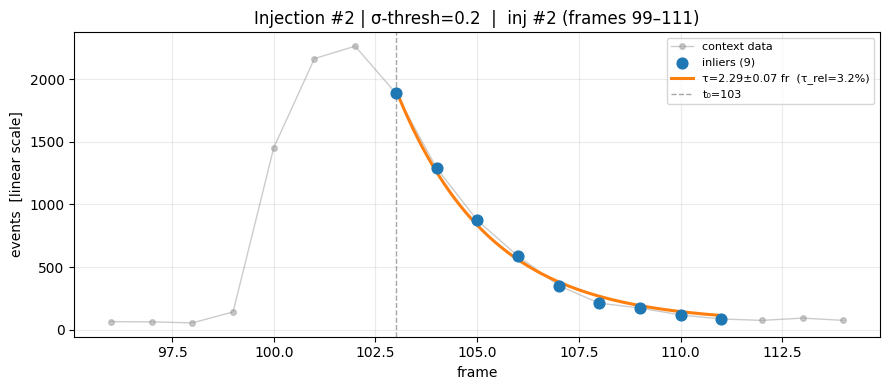

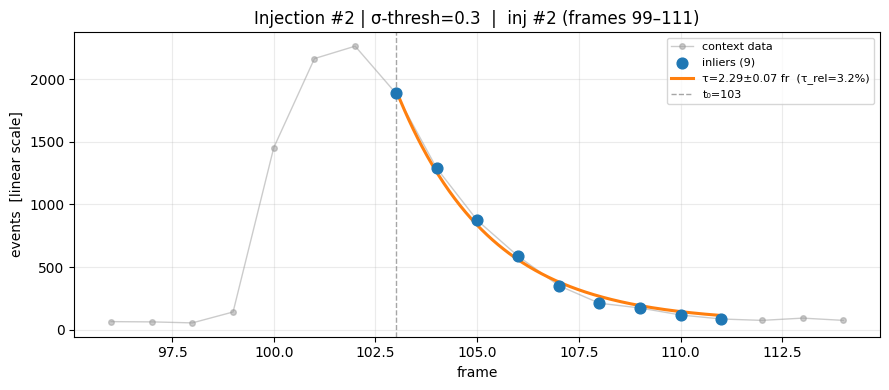

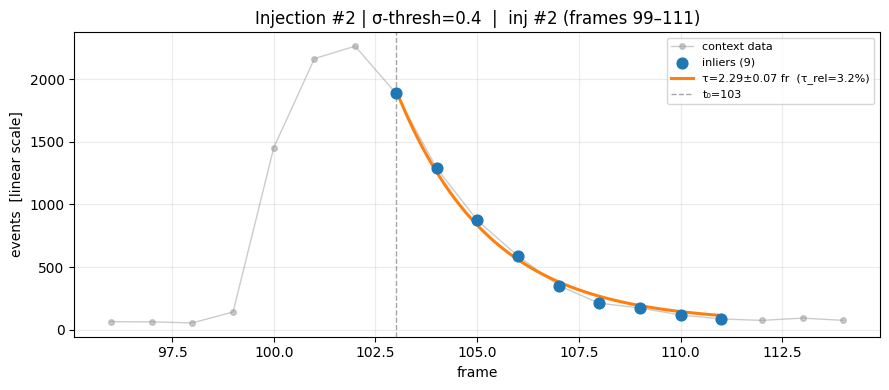

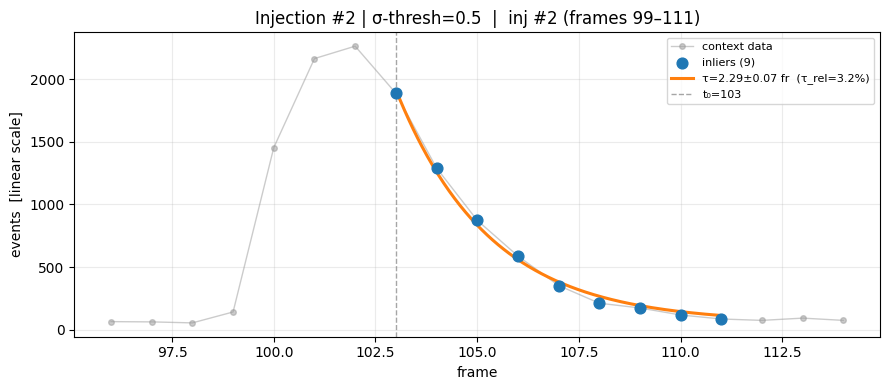

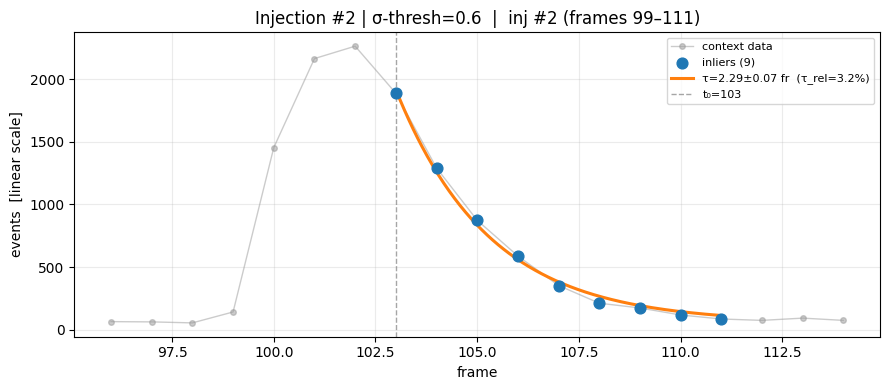

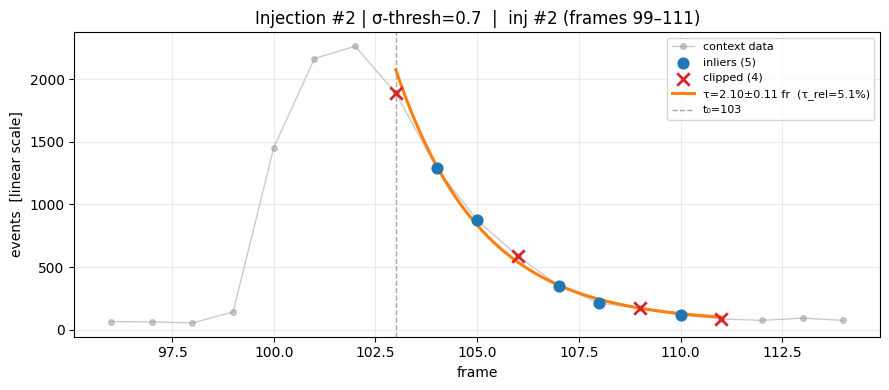

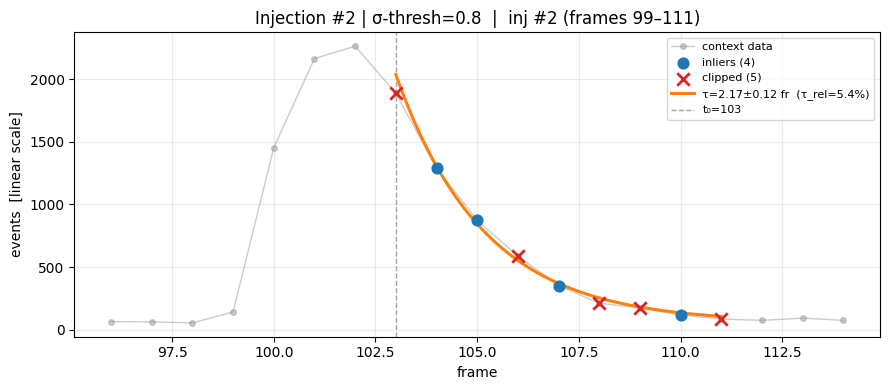

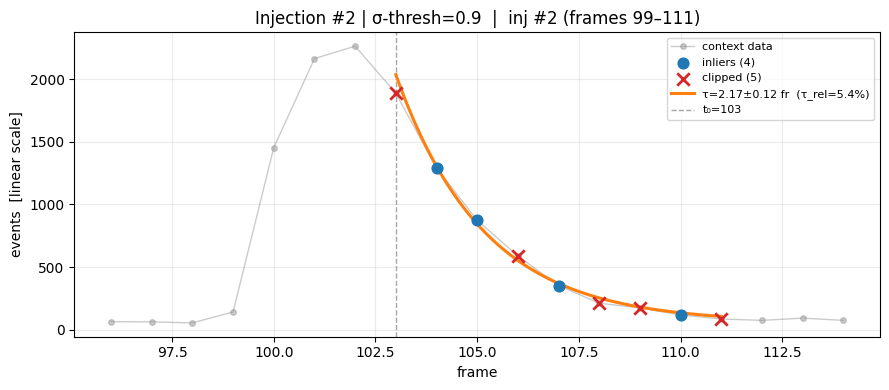

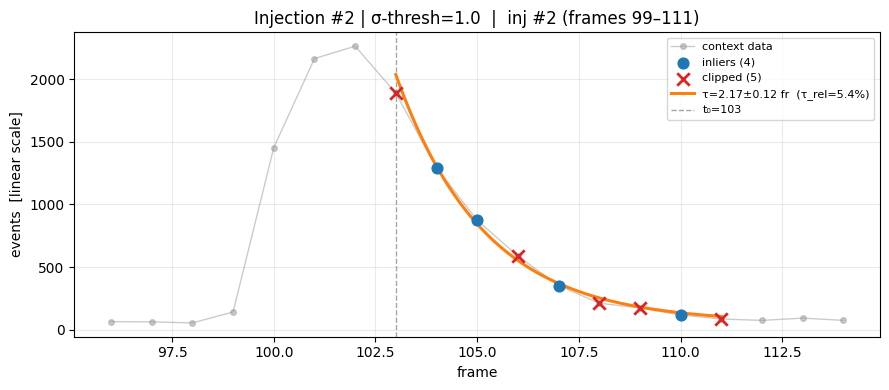

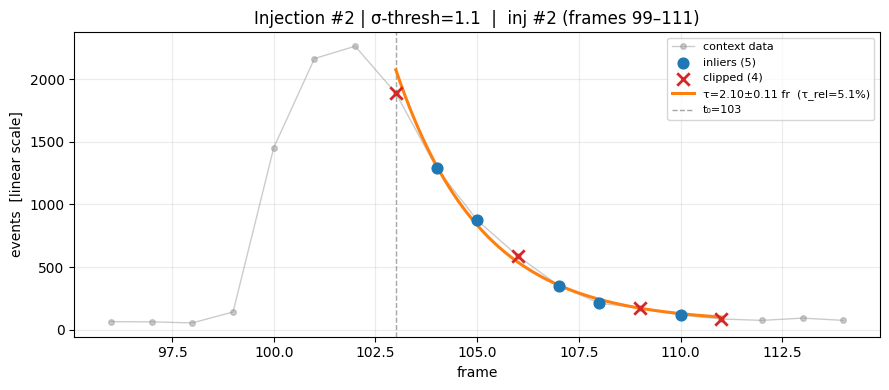

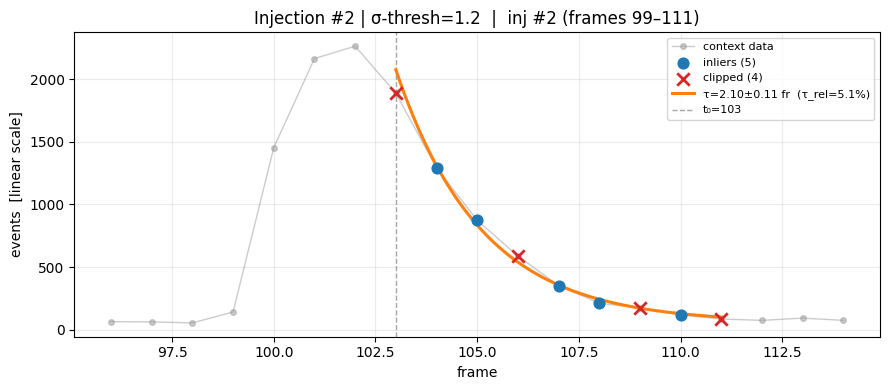

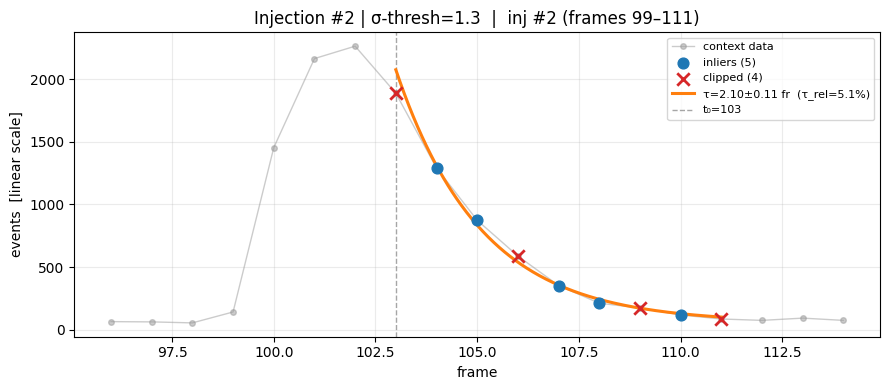

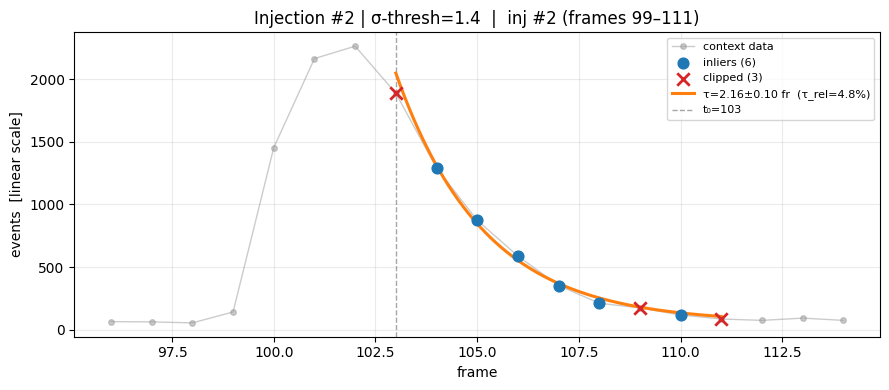

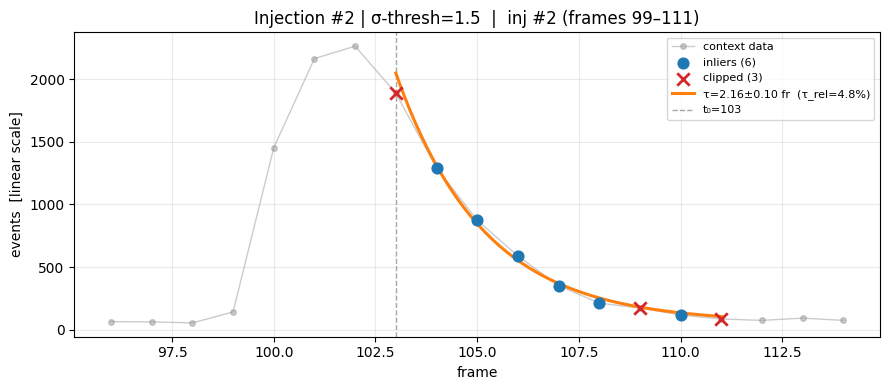

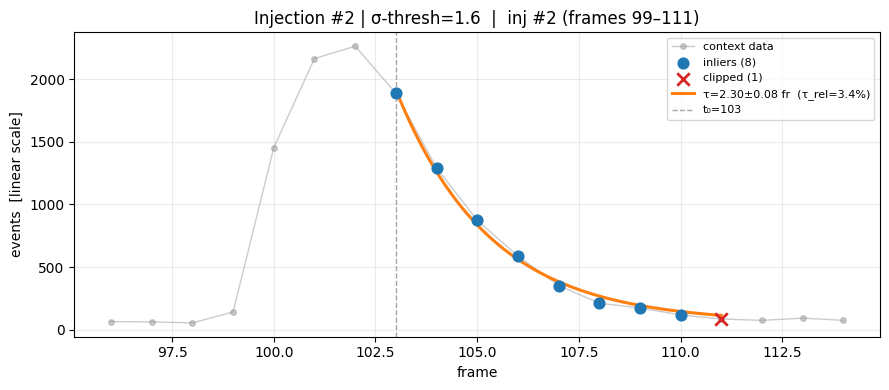

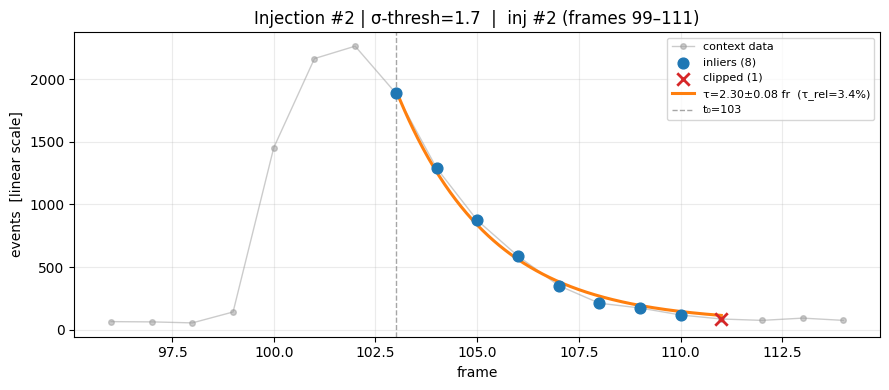

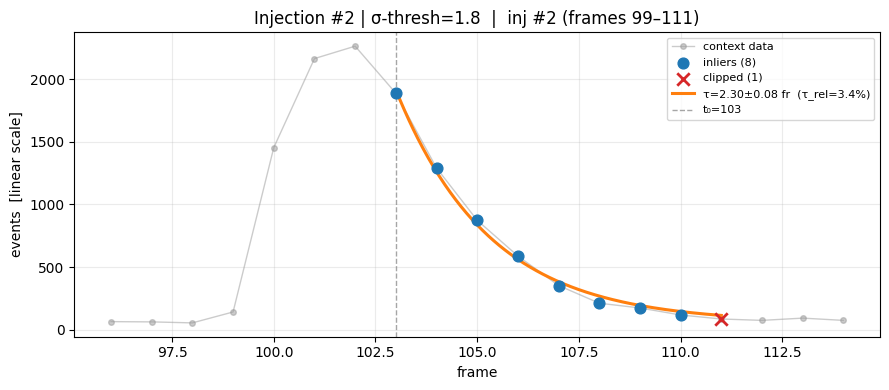

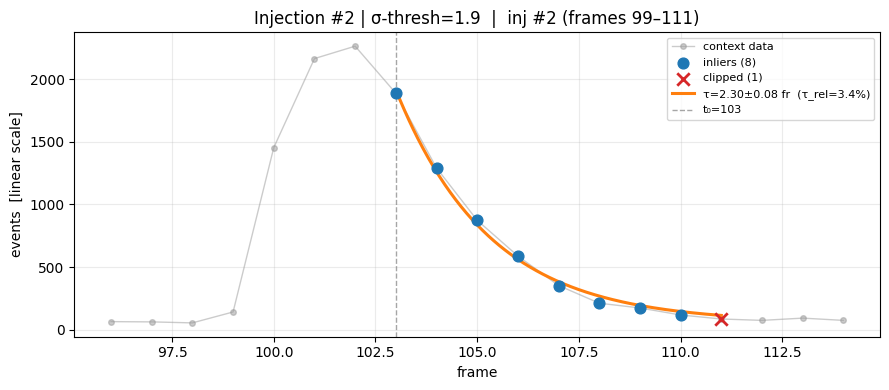

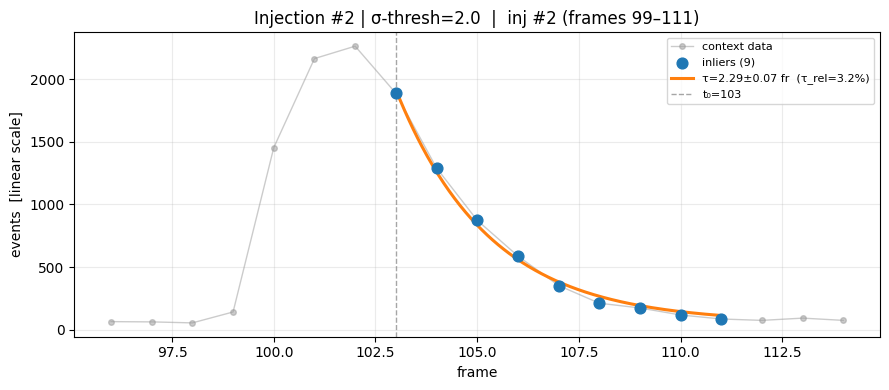

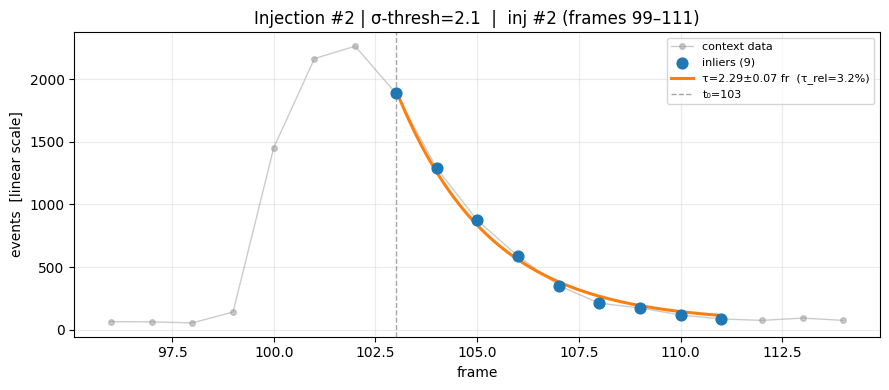

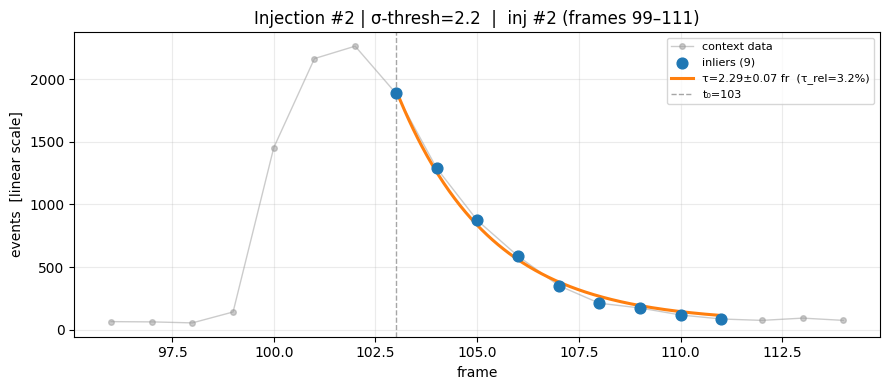

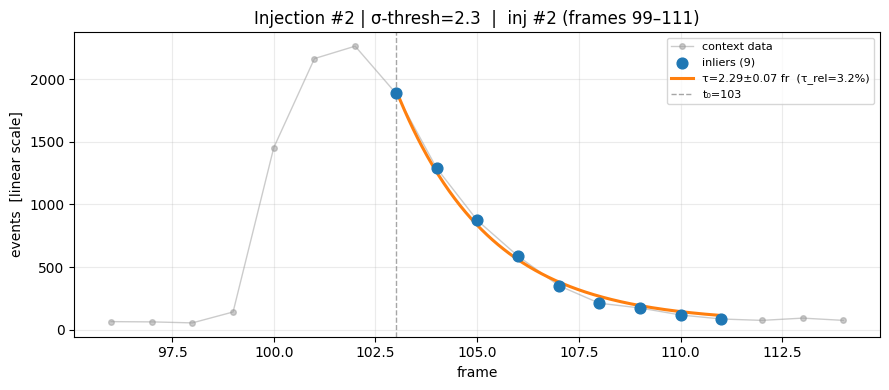

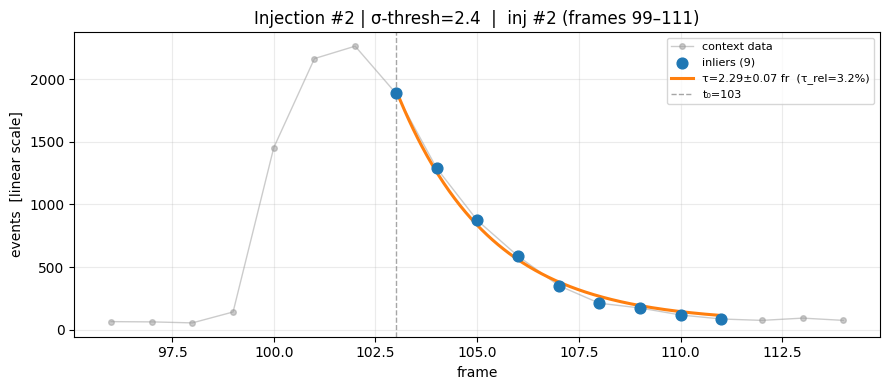

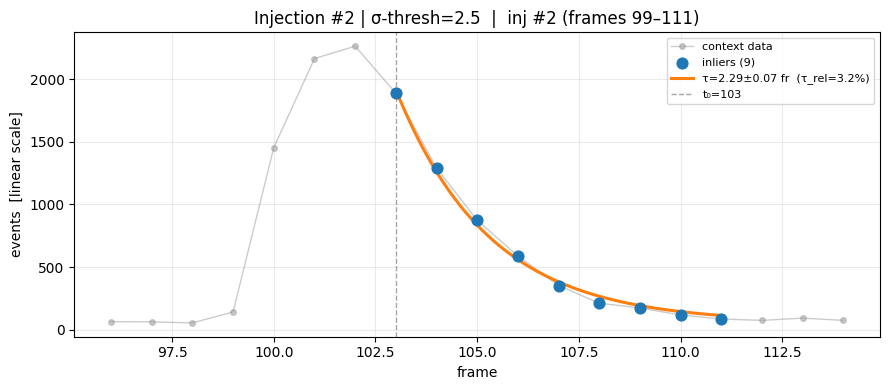

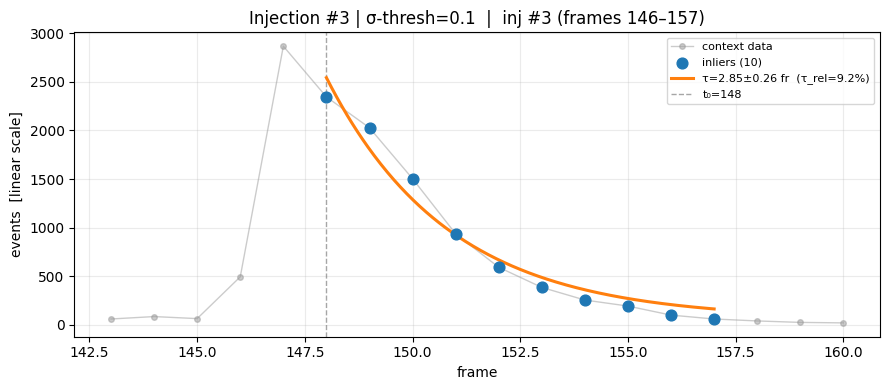

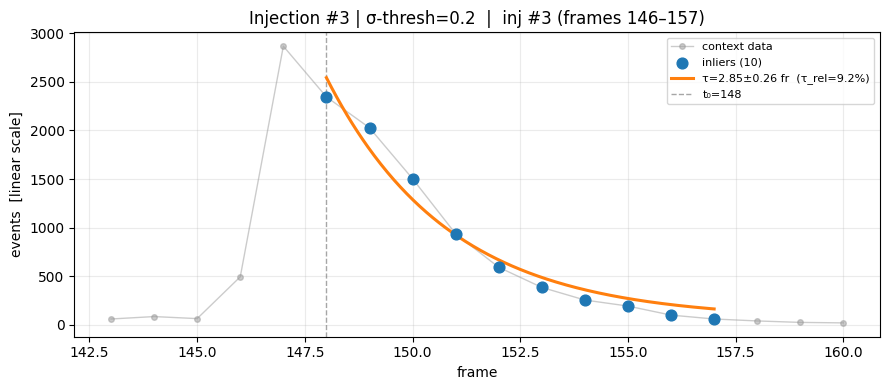

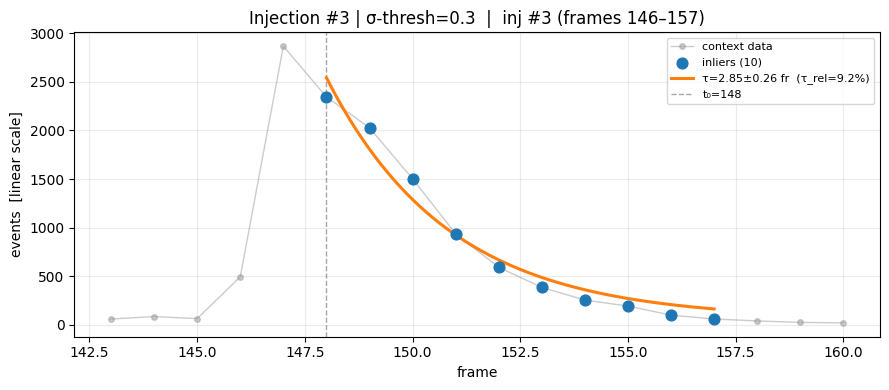

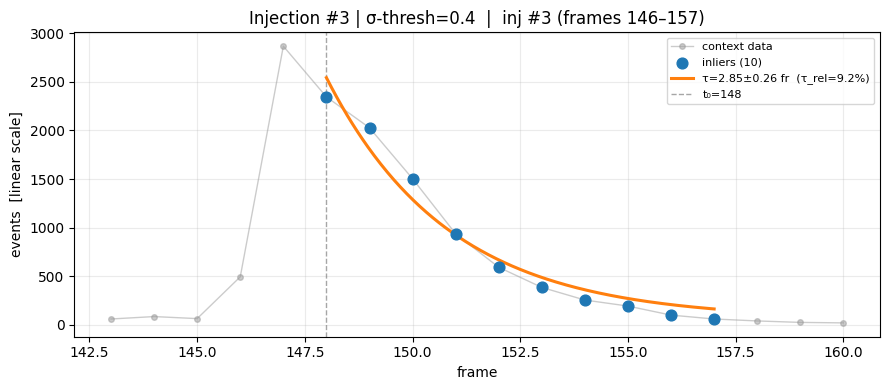

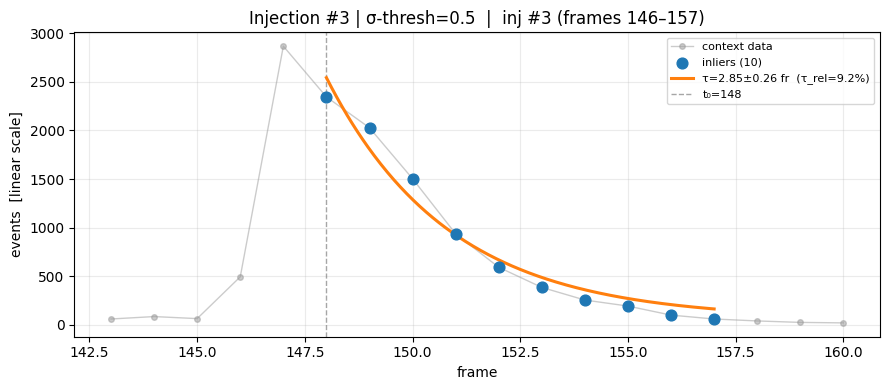

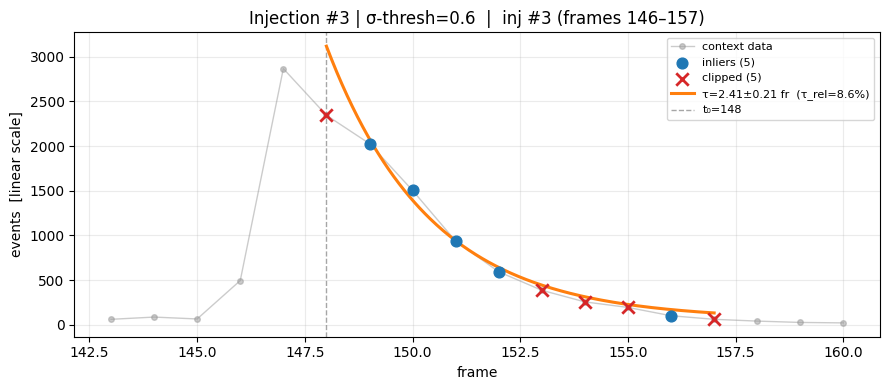

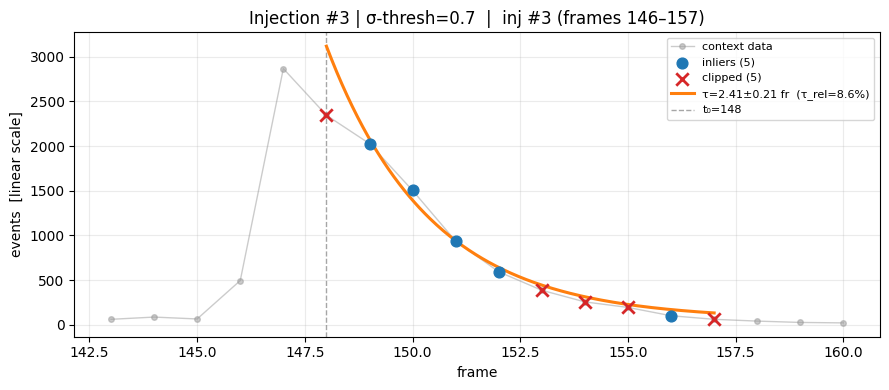

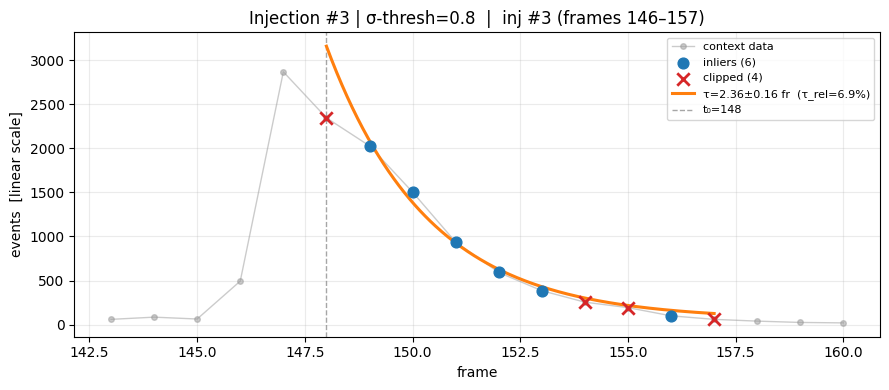

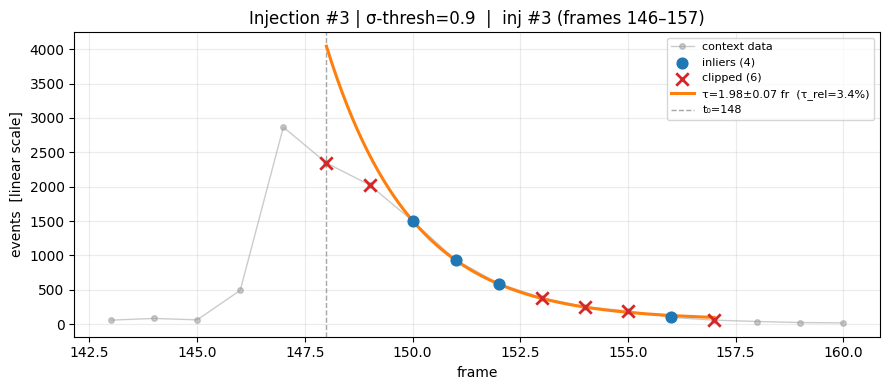

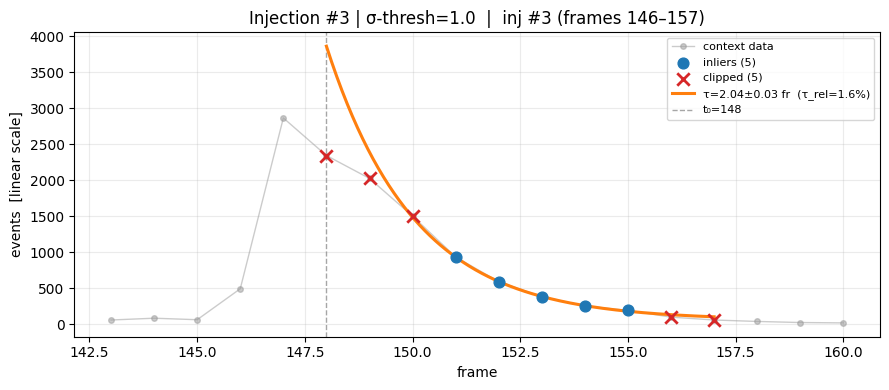

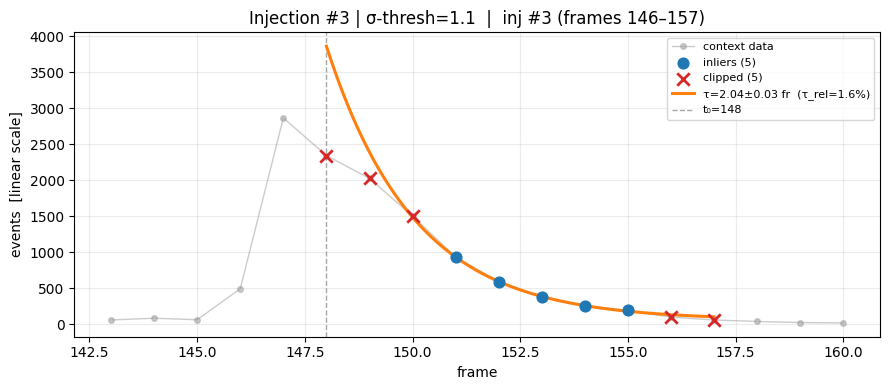

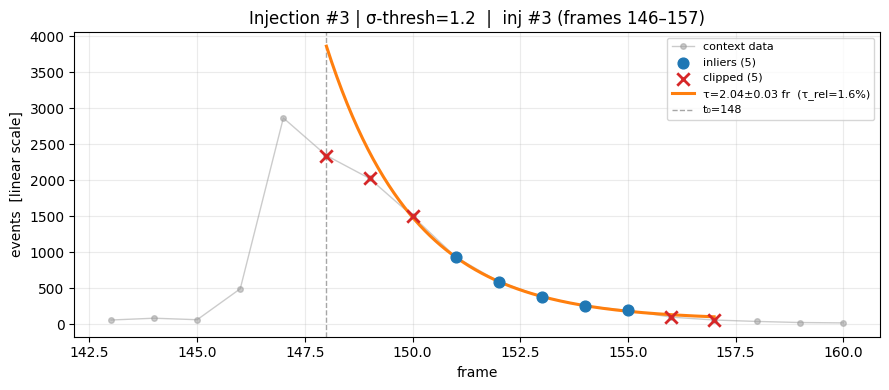

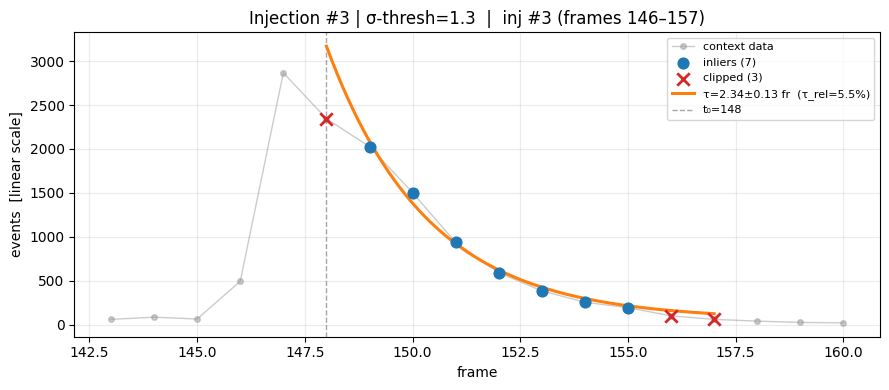

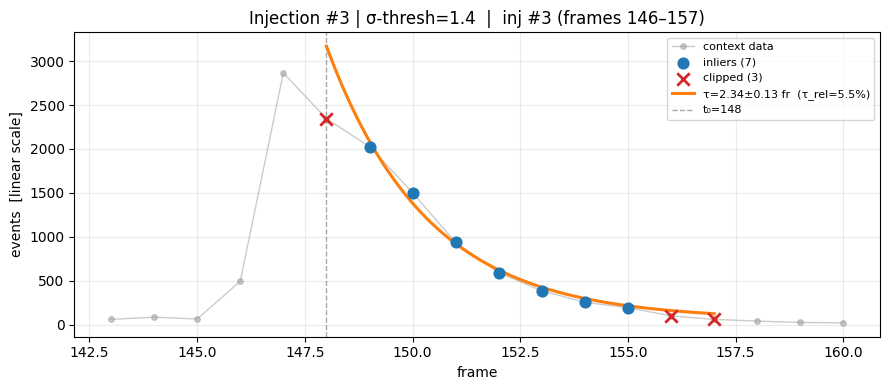

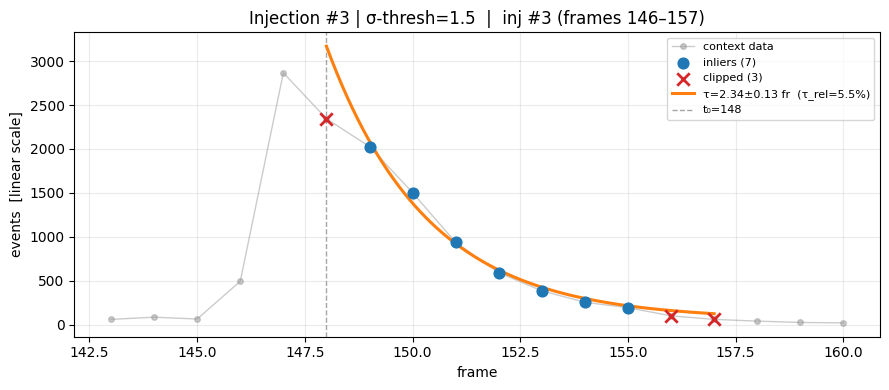

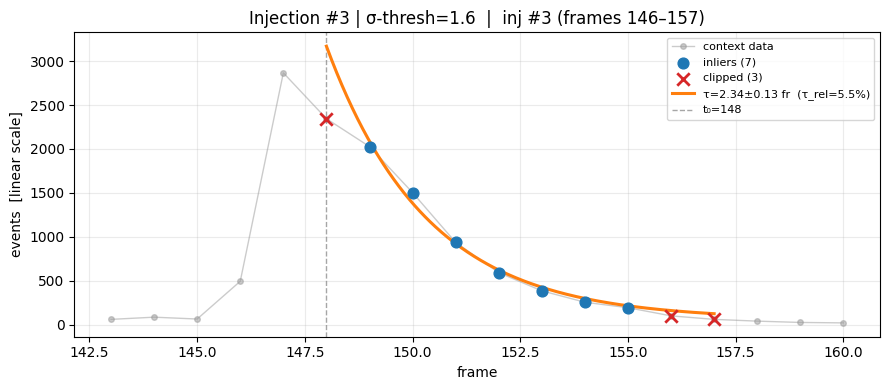

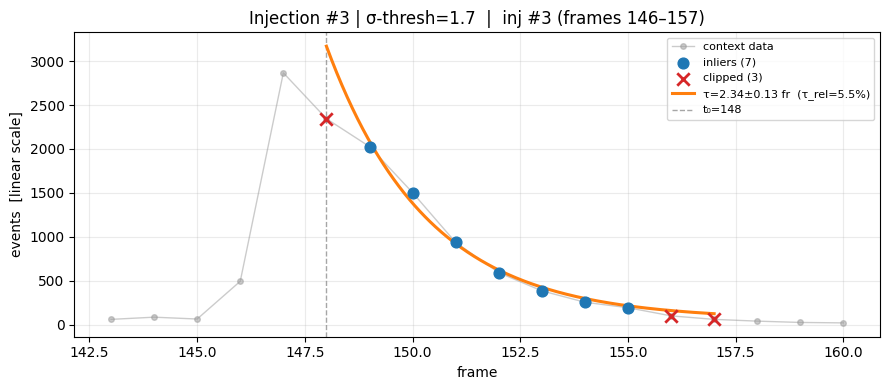

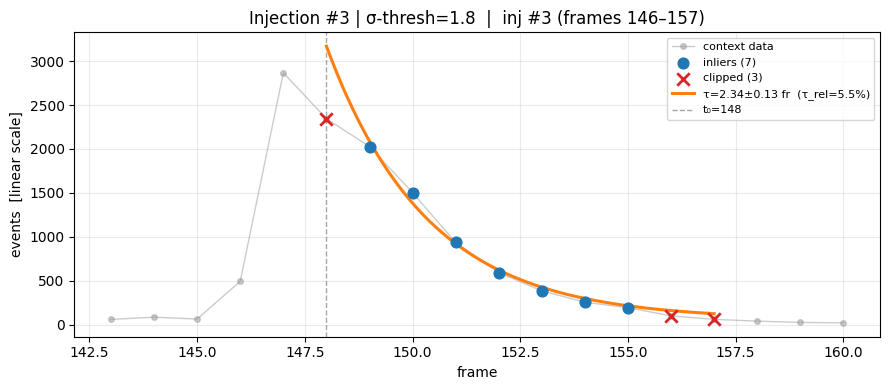

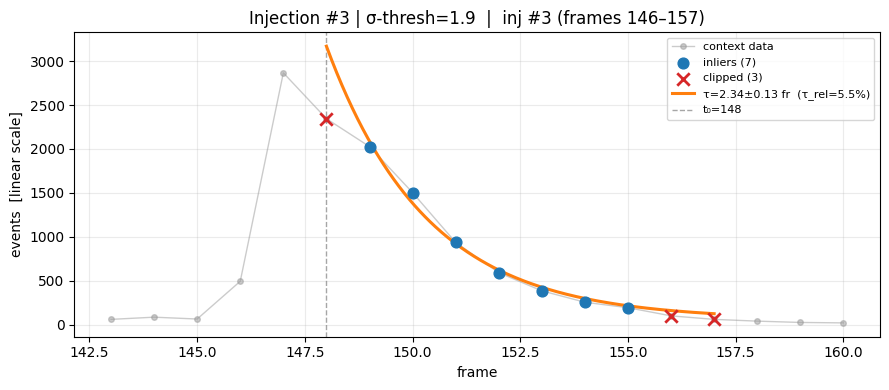

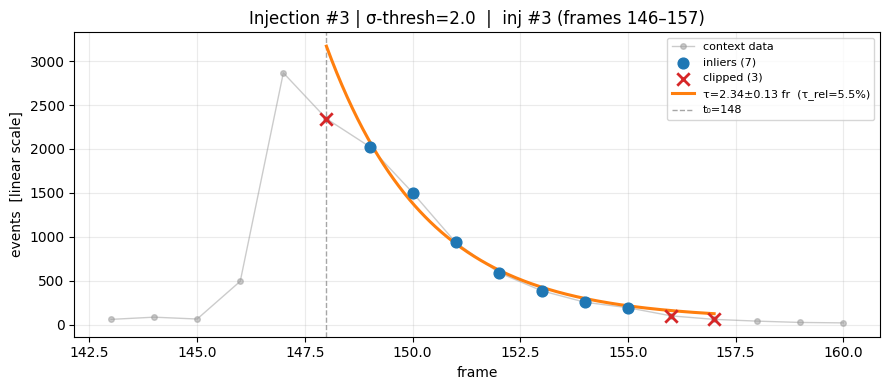

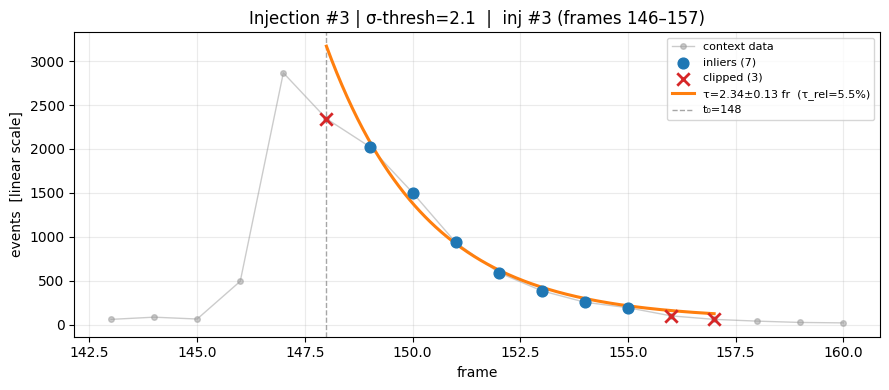

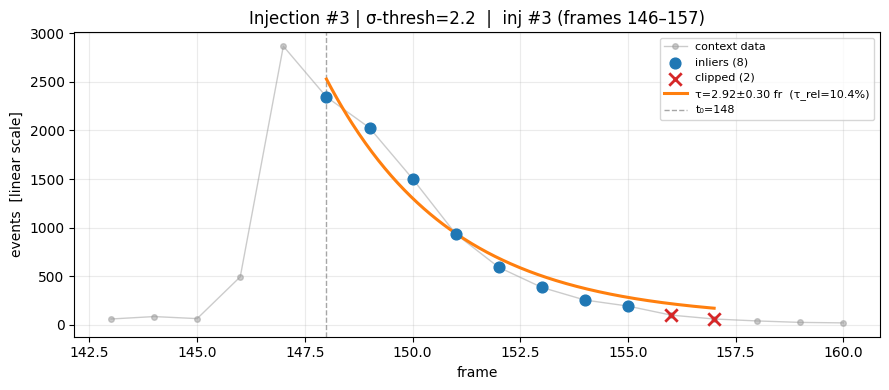

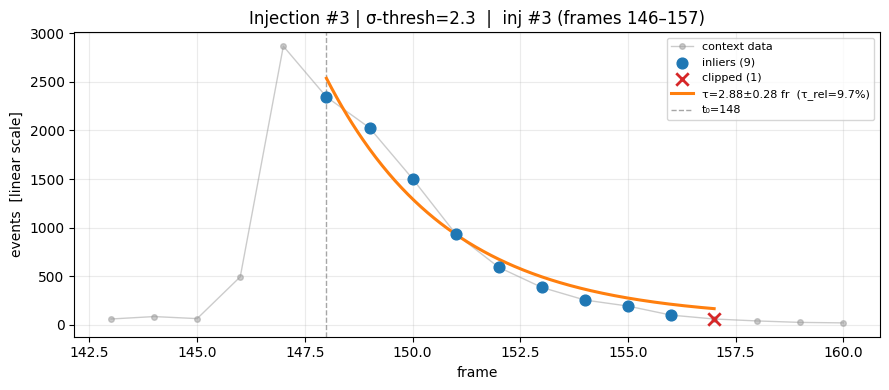

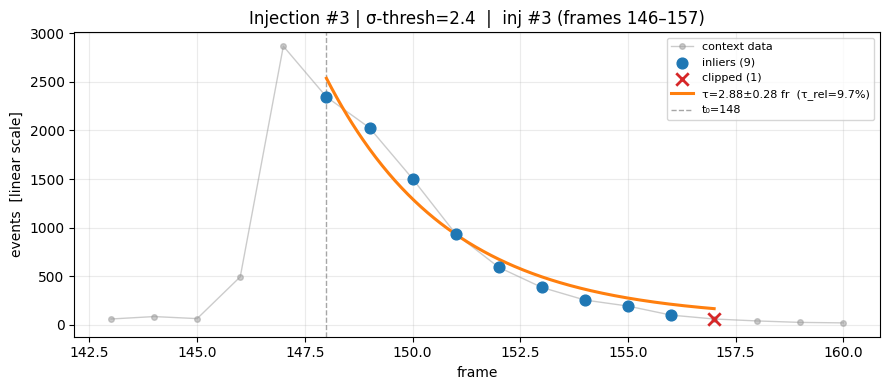

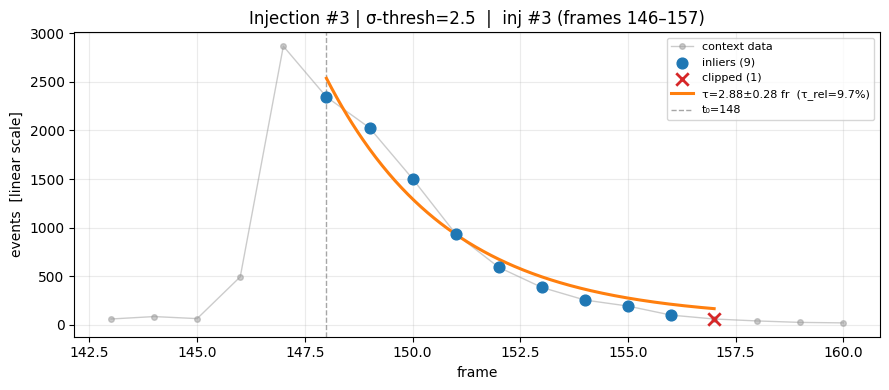

In [16]:
"""Cell 13 — Re-draw Cell 11 and Cell 12 sweeps in linear (non-log) y-scale.

This keeps the same threshold range and one-plot-per-threshold style,
but removes logarithmic scaling so absolute count differences are visible.
"""

thresholds = np.round(np.arange(0.1, 2.51, 0.1), 2)


def plot_threshold_sweep_linear(trace_obj, inj, thresholds_arr, title_prefix=""):
    """Draw one linear-scale fit plot per sigma threshold for a single injection."""
    t_fn_local = trace_obj.frame_numbers
    t_v_local  = trace_obj.values

    # Small context window around the injection for visual continuity.
    ctx_lo_local = max(0, inj.start_frame - 3)
    ctx_hi_local = min(int(t_fn_local[-1]), inj.finish_frame + 3)
    ctx_local    = (t_fn_local >= ctx_lo_local) & (t_fn_local <= ctx_hi_local)

    for th in thresholds_arr:
        r_local = fit_sigma_clip(trace_obj, inj, sigma_thresh=th)

        fig, ax = plt.subplots(figsize=(9, 4))

        # Plot local context with faint styling so fit diagnostics stand out.
        ax.plot(
            t_fn_local[ctx_local],
            t_v_local[ctx_local],
            "o-",
            ms=4,
            lw=1,
            color="0.6",
            alpha=0.5,
            label="context data",
        )

        if r_local["success"]:
            t_a = r_local["t_all"]
            y_a = r_local["y_all"]
            im  = r_local["inlier_mask"]

            # Inliers used by the fit.
            ax.scatter(
                t_a[im],
                y_a[im],
                s=60,
                color="tab:blue",
                zorder=4,
                label=f"inliers ({im.sum()})",
            )

            # Sigma-clipped points that were rejected.
            if (~im).any():
                ax.scatter(
                    t_a[~im],
                    y_a[~im],
                    s=80,
                    marker="x",
                    color="tab:red",
                    linewidths=2,
                    zorder=5,
                    label=f"clipped ({(~im).sum()})",
                )

            # Fitted exponential curve.
            t_c = np.linspace(float(t_a[0]), float(t_a[-1]), 300)
            y_c = _exp_model(t_c, r_local["A"], r_local["tau"], r_local["t_0"], r_local["C_bg"])
            ax.plot(
                t_c,
                y_c,
                color="tab:orange",
                lw=2.2,
                zorder=3,
                label=(
                    f"τ={r_local['tau']:.2f}±{r_local['tau_err']:.2f} fr  "
                    f"(τ_rel={r_local['tau_err_rel']*100:.1f}%)"
                ),
            )

            ax.axvline(
                r_local["t_0"],
                color="gray",
                ls="--",
                lw=1,
                alpha=0.7,
                label=f"t₀={int(r_local['t_0'])}",
            )
        else:
            ax.text(
                0.5,
                0.5,
                f"failed: {r_local['message']}",
                transform=ax.transAxes,
                ha="center",
                color="red",
                fontsize=10,
            )

        # Linear y-scale (intentionally no ax.set_yscale('log')).
        ax.set_xlabel("frame")
        ax.set_ylabel("events  [linear scale]")
        ax.set_title(
            f"{title_prefix} σ-thresh={th:.1f}  |  inj #{inj.injection_no} "
            f"(frames {inj.start_frame}–{inj.finish_frame})"
        )
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)
        fig.tight_layout()
        plt.show()


# Cell 11 equivalent (injection #2), but linear scale.
plot_threshold_sweep_linear(test_trace, inj2_test, thresholds, title_prefix="Injection #2 |")

# Cell 12 equivalent (injection #3), but linear scale.
plot_threshold_sweep_linear(test_trace, inj3_test, thresholds, title_prefix="Injection #3 |")


# fit all the dis

Loaded cached discharges: 16
Missing cache: 0
Failed cache load: 0

2025-04-29--10-19: injections=4 (trimmed 17 frames per side)


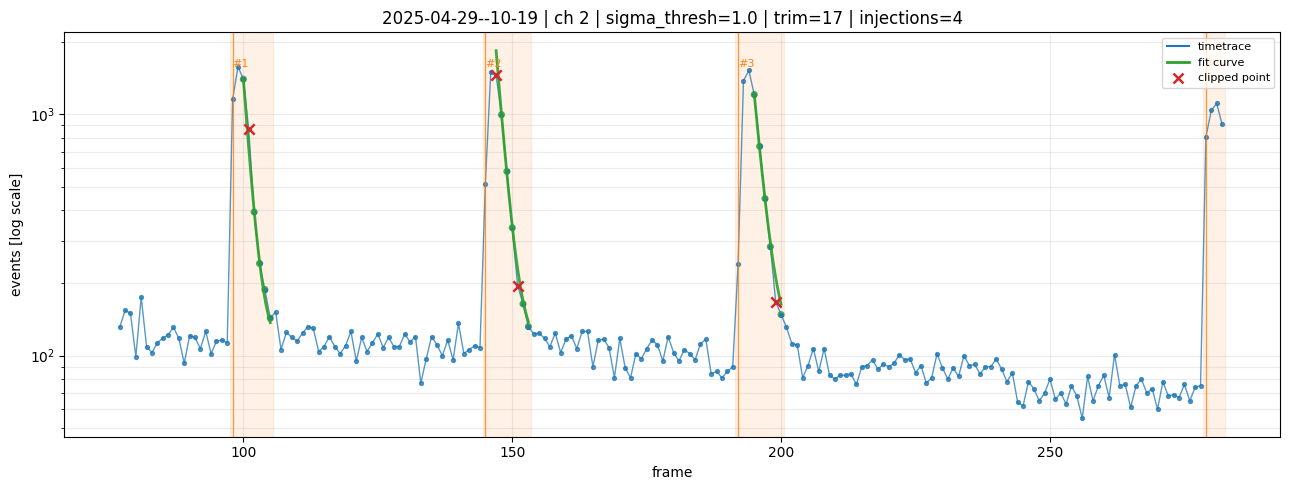


2025-04-29--10-24: injections=4 (trimmed 17 frames per side)


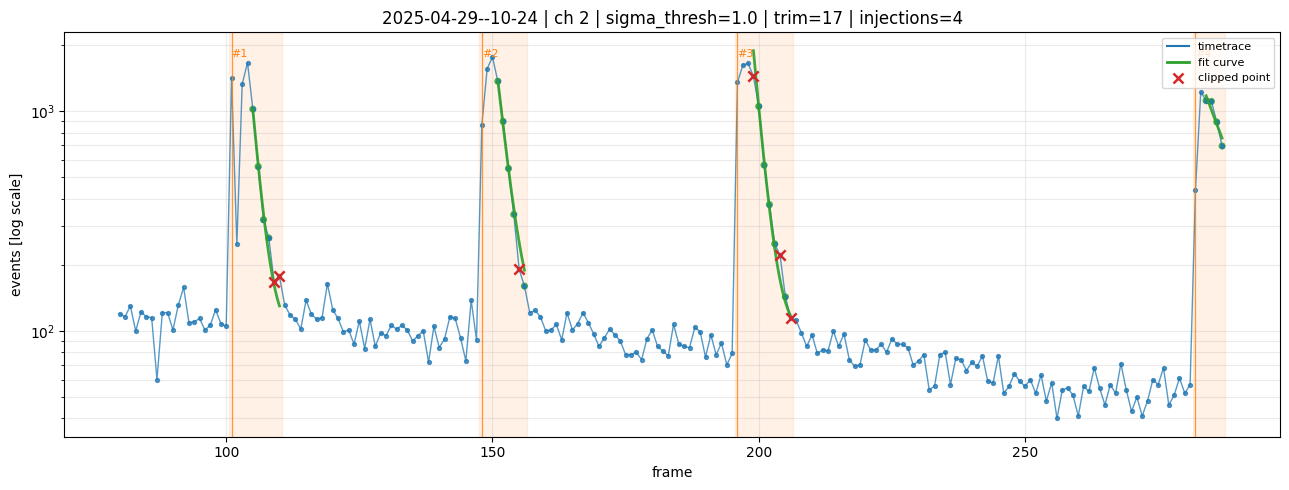


2025-04-29--10-42: injections=1 (trimmed 17 frames per side)


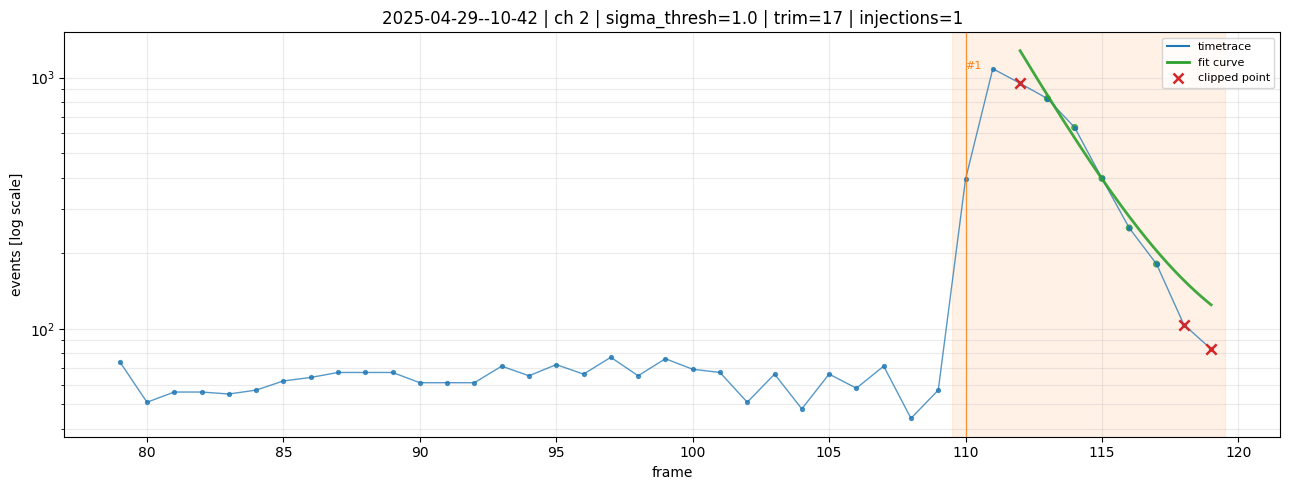


2025-04-29--10-49: injections=1 (trimmed 17 frames per side)


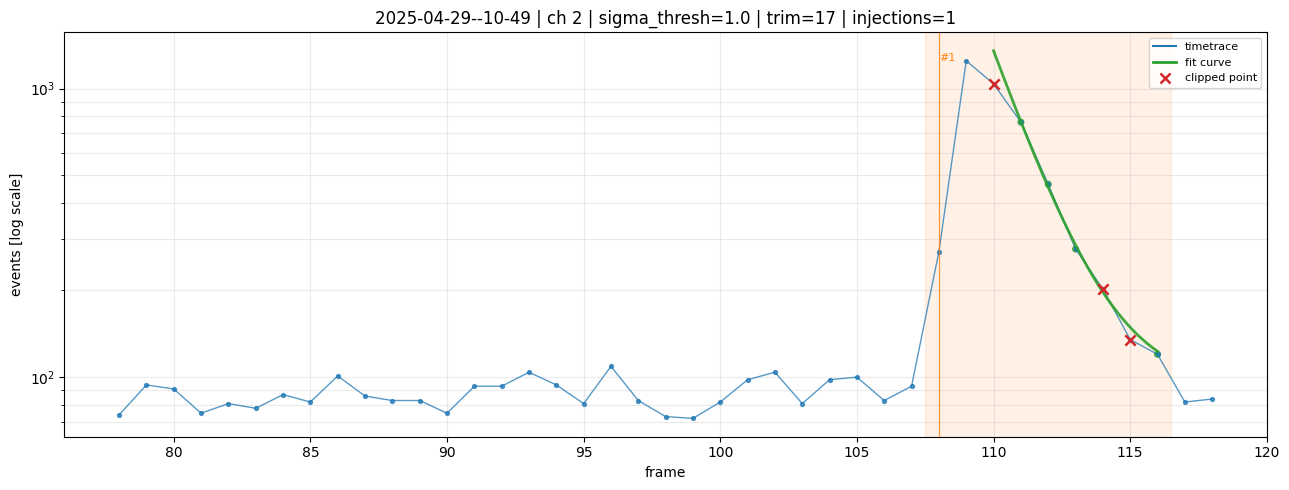


2025-04-29--11-17: injections=2 (trimmed 17 frames per side)


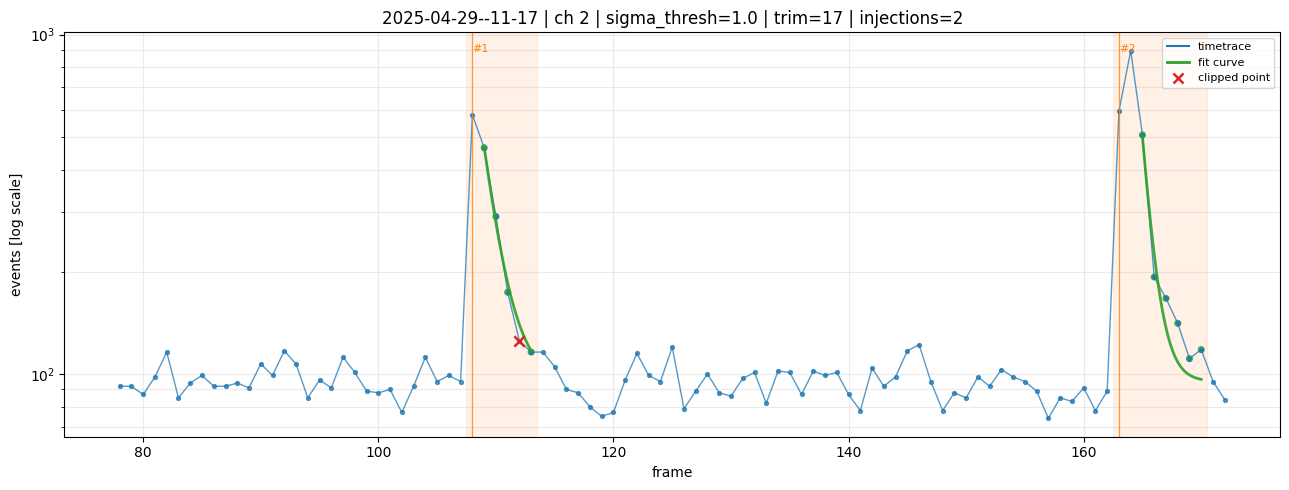

C:\Users\Superadmin\AppData\Local\Temp\ipykernel_15868\1736965081.py:242: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(



2025-04-29--11-19: injections=4 (trimmed 17 frames per side)


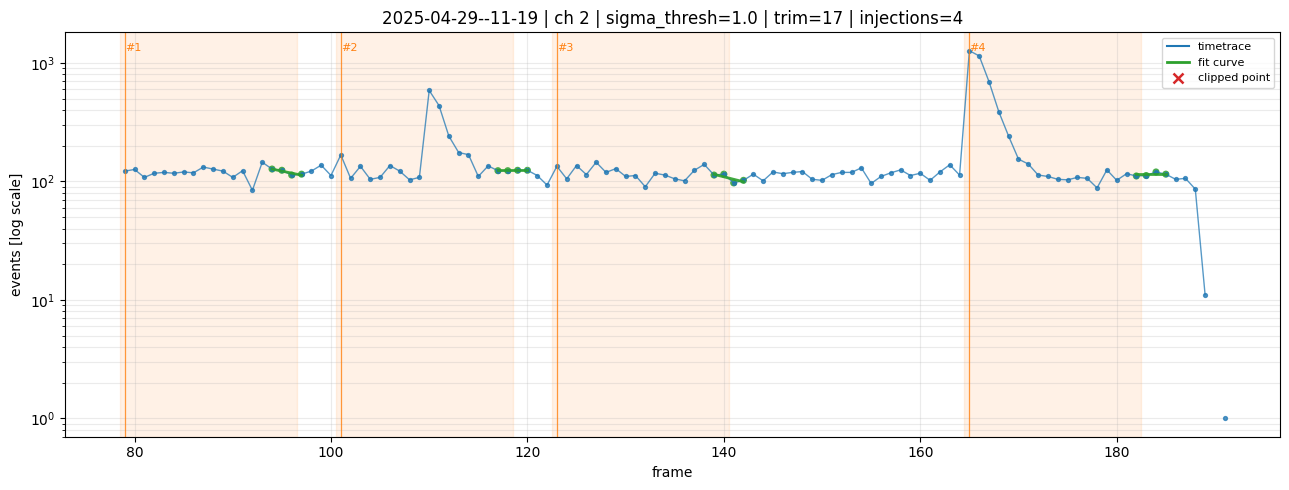


2025-04-29--11-23: injections=3 (trimmed 17 frames per side)


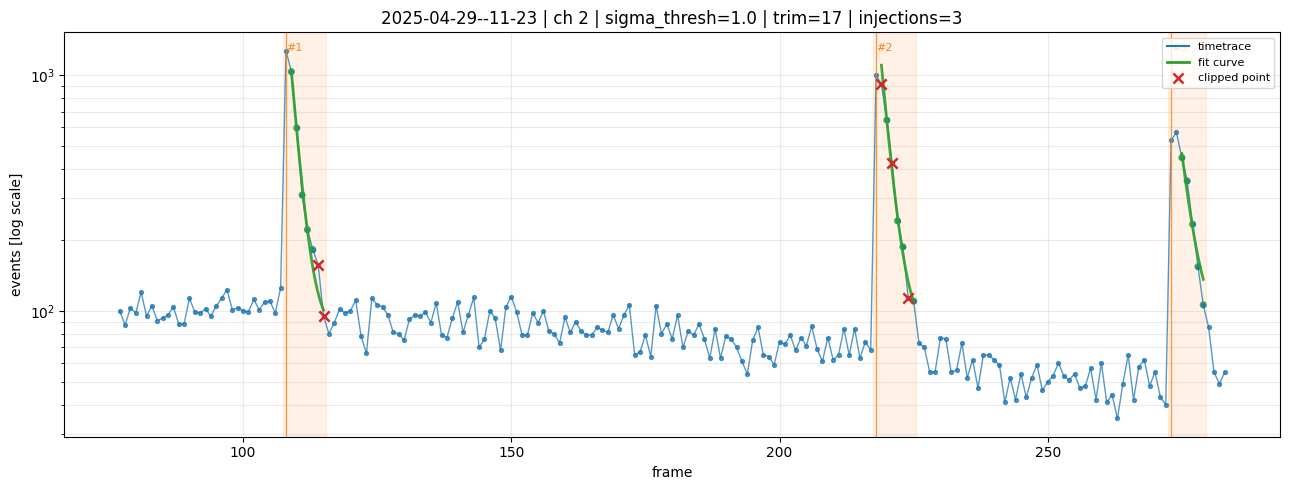


2025-04-29--11-32: injections=3 (trimmed 17 frames per side)


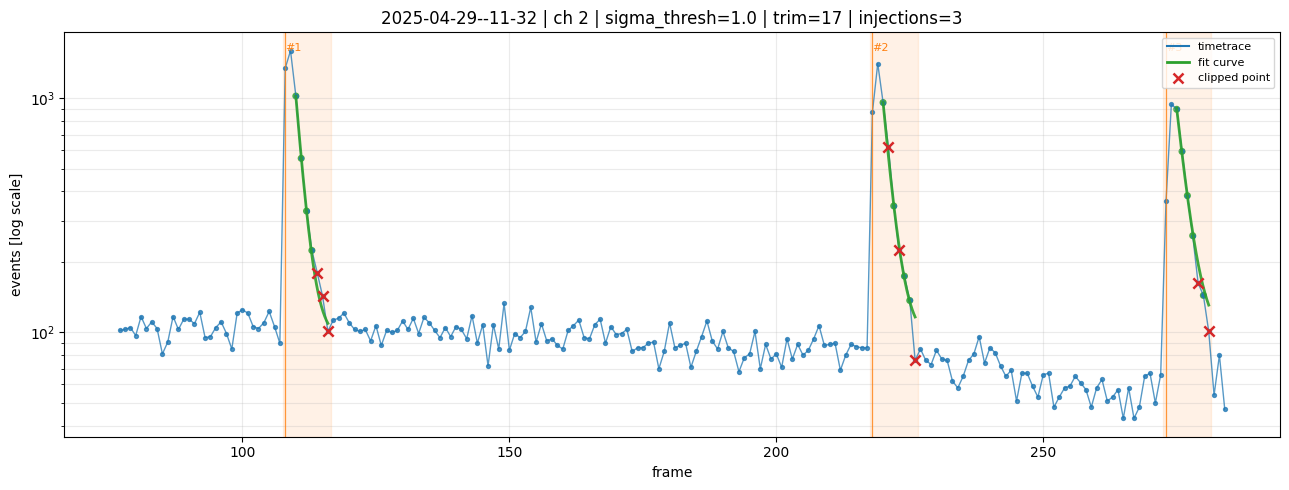


2025-04-29--11-37: injections=1 (trimmed 17 frames per side)


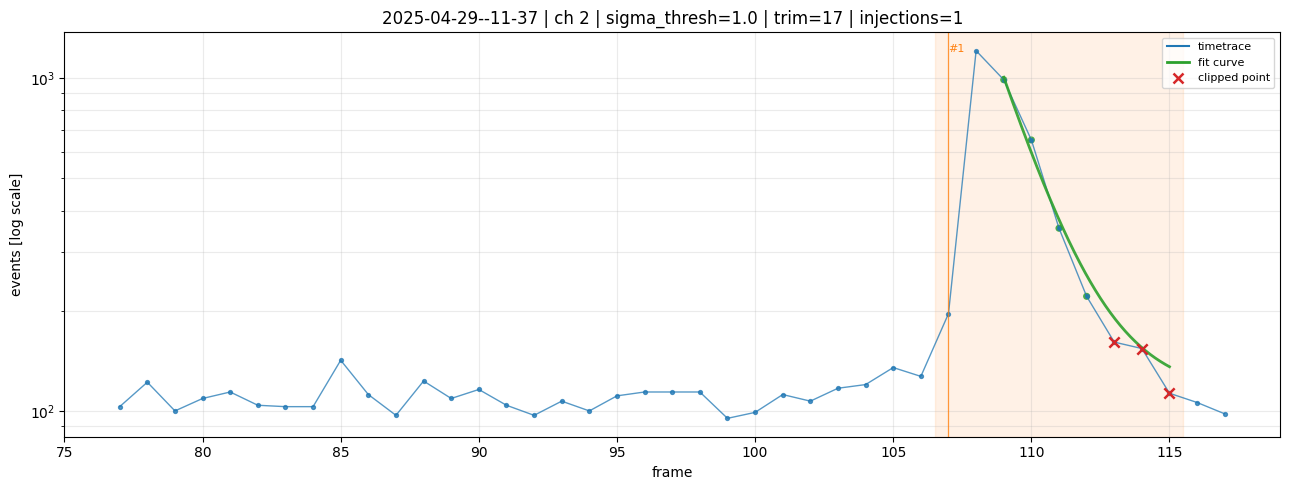


2025-04-29--12-14: injections=3 (trimmed 17 frames per side)


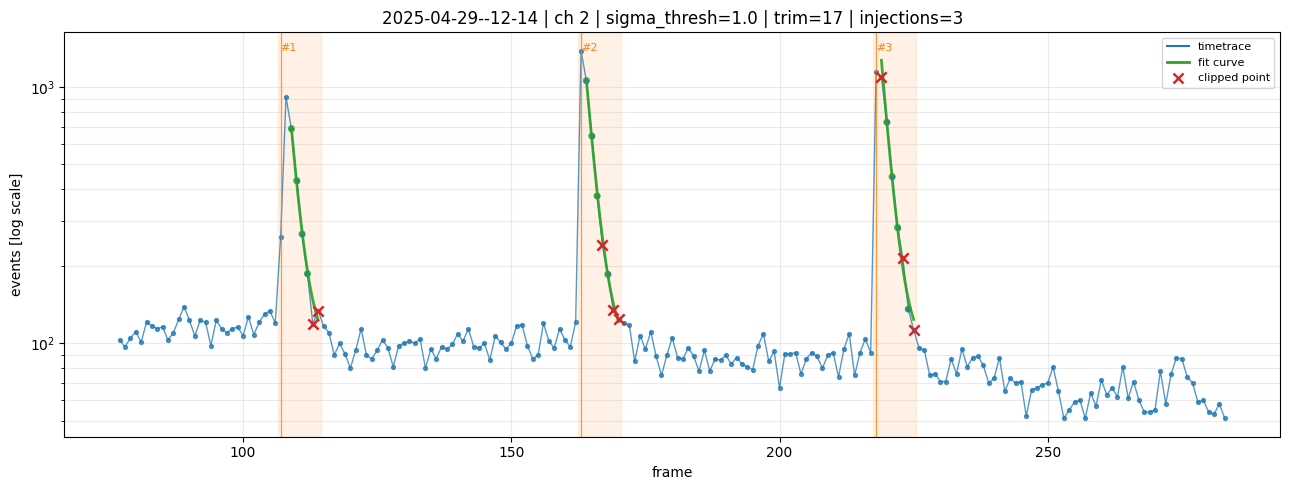


2025-04-29--12-28: injections=5 (trimmed 17 frames per side)


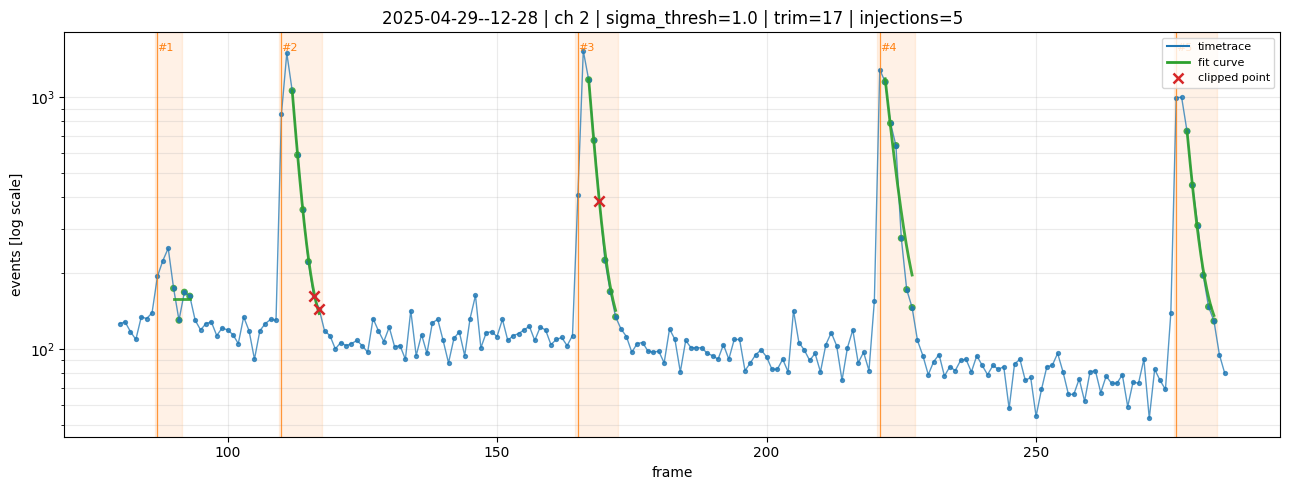


2025-04-29--12-50: injections=1 (trimmed 17 frames per side)


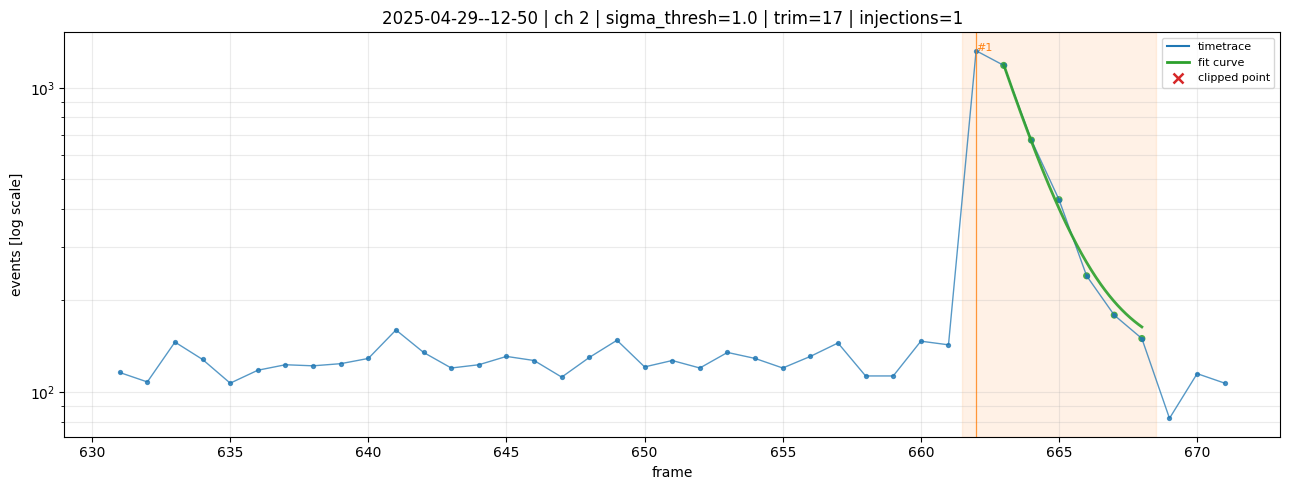


2025-04-29--12-58: injections=3 (trimmed 17 frames per side)


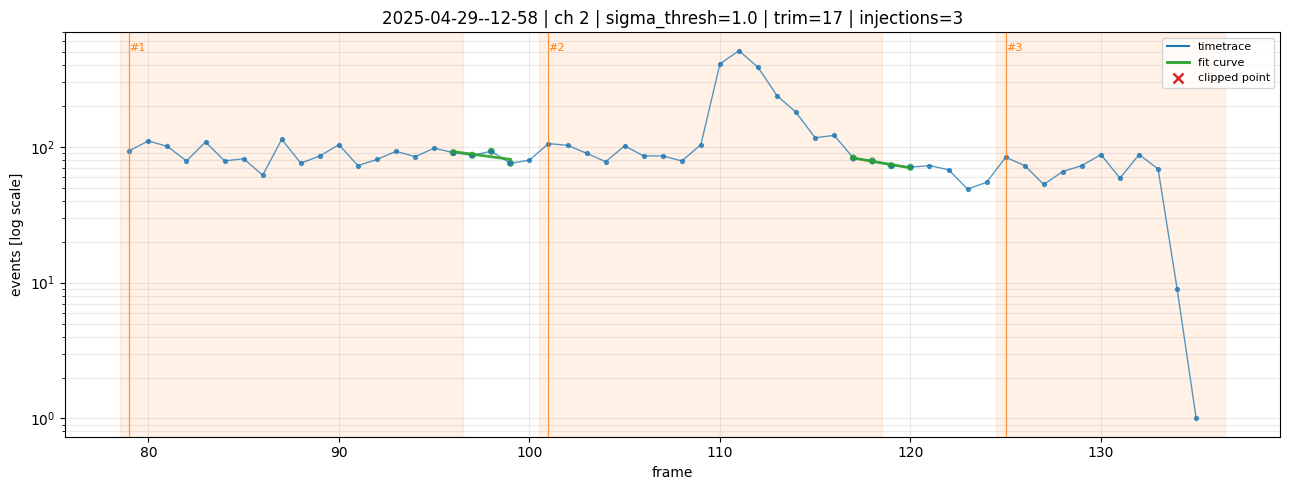


2025-04-29--13-17: injections=1 (trimmed 17 frames per side)


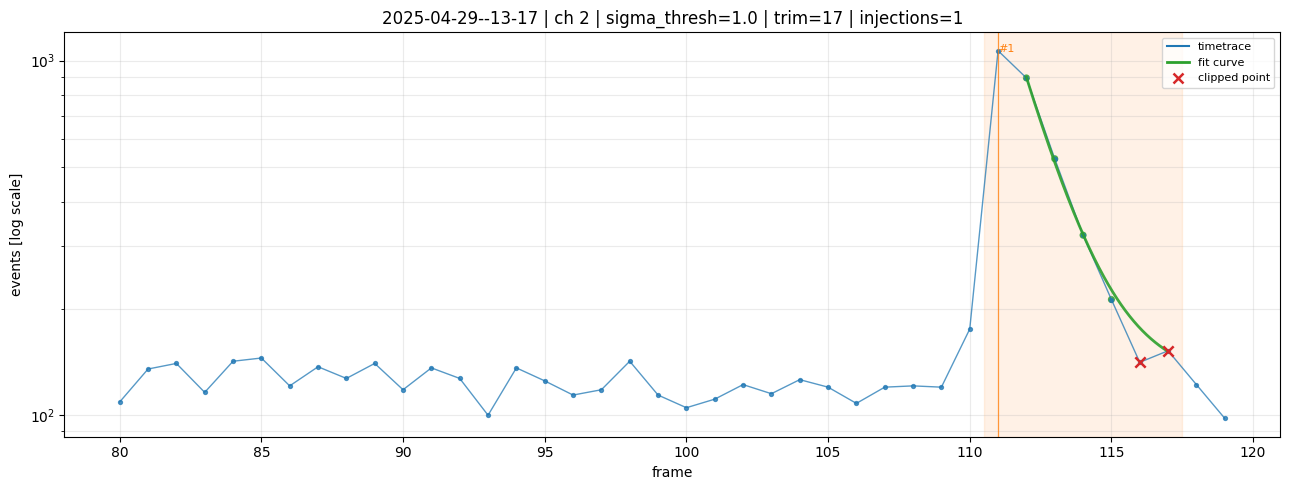


2025-04-29--13-51: injections=4 (trimmed 17 frames per side)


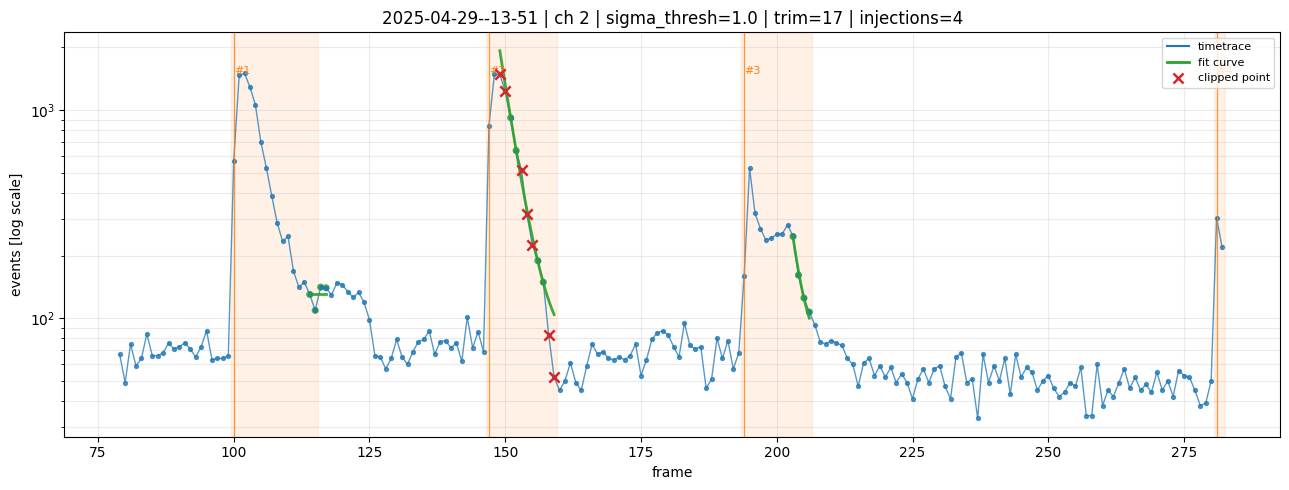


test: injections=4 (trimmed 17 frames per side)


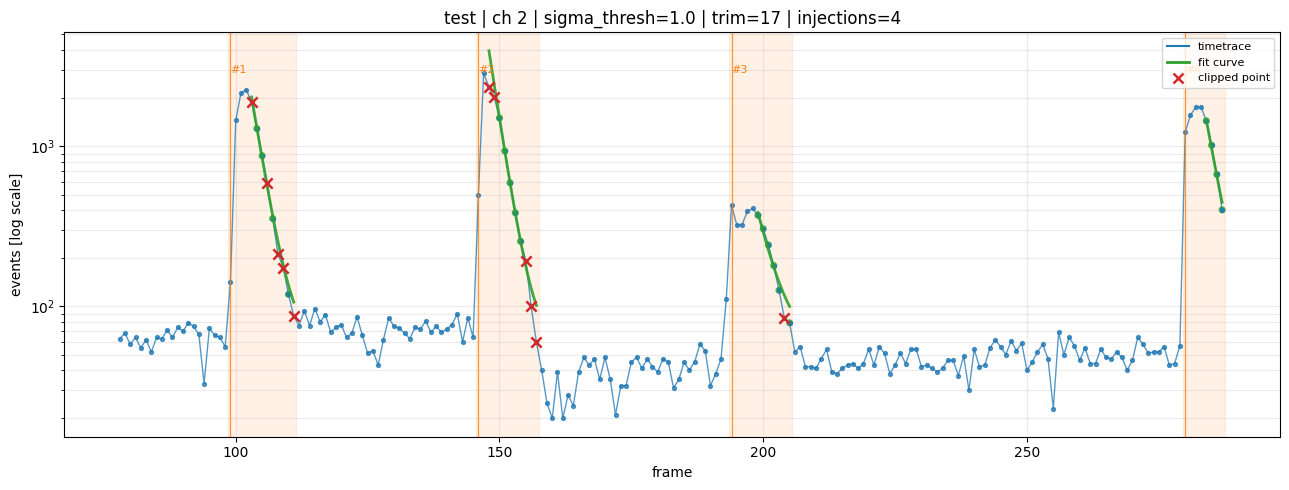


Cache loading summary:
 discharge_folder status                                                                            cache_file error
2025-04-29--10-19 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-19\cache\discharge_object.pkl      
2025-04-29--10-24 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-24\cache\discharge_object.pkl      
2025-04-29--10-42 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-42\cache\discharge_object.pkl      
2025-04-29--10-49 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--10-49\cache\discharge_object.pkl      
2025-04-29--11-17 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-17\cache\discharge_object.pkl      
2025-04-29--11-19 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-19\cache\discharge_object.pkl      
2025-04-29--11-23 loaded D:\ℱ Sci\IFPiLM\1st task\data\discharges\2025-04-29--11-23\cache\discharge_object.pkl      
2025-04-29--11-32 loaded D:\ℱ Sci\IFPiLM

In [4]:
"""Cell 14 — Cached all-discharge run: detect + fit (sigma=1) + log-scale plots.

Workflow:
1) Load every cached discharge object from data/discharges/*/cache/discharge_object.pkl
2) Build channel timetrace, trim 5 frames at both ends, and detect injections
3) Fit each injection with fit_sigma_clip(sigma_thresh=1.0)
   (fit_sigma_clip internally uses find_first_falling_frame)
4) Plot one figure per discharge (log y-scale):
   - full (trimmed) timetrace
   - highlighted injection windows
   - fitted curves per injection
   - clipped points marked with red X
"""

from pha_lib.model import TimeTrace

CACHE_NAME = "discharge_object.pkl"
BASE_DISCHARGES_DIR = ROOT / "data" / "discharges"
SIGMA_THRESH = 1.0
TRIM_FRAMES = 17

cache_rows = []

# --- gather cached discharges ---
for folder in sorted(p for p in BASE_DISCHARGES_DIR.iterdir() if p.is_dir()):
    cache_file = folder / "cache" / CACHE_NAME
    if not cache_file.exists():
        cache_rows.append({
            "discharge_folder": folder.name,
            "status": "missing_cache",
            "cache_file": str(cache_file),
            "error": "",
        })
        continue

    try:
        discharge_obj = pd.read_pickle(cache_file)
        cache_rows.append({
            "discharge_folder": folder.name,
            "status": "loaded",
            "cache_file": str(cache_file),
            "error": "",
            "discharge_obj": discharge_obj,
        })
    except Exception as exc:
        cache_rows.append({
            "discharge_folder": folder.name,
            "status": "failed",
            "cache_file": str(cache_file),
            "error": str(exc),
        })

loaded_rows = [r for r in cache_rows if r["status"] == "loaded"]
print(f"Loaded cached discharges: {len(loaded_rows)}")
print(f"Missing cache: {sum(r['status']=='missing_cache' for r in cache_rows)}")
print(f"Failed cache load: {sum(r['status']=='failed' for r in cache_rows)}")

# --- process each loaded discharge and plot ---
for row in loaded_rows:
    d_obj = row["discharge_obj"]
    d_id = getattr(d_obj, "discharge_id", row["discharge_folder"])

    if CHANNEL_ID not in d_obj.channels:
        print(f"[SKIP] {d_id}: channel {CHANNEL_ID} not found")
        continue

    # Build timetrace for this discharge/channel.
    ch = d_obj.channels[CHANNEL_ID]
    tr_full = integrate_energy_window(ch, LINE_E, HALF_W)

    # Trim fixed edge frames from beginning and end before detection/fitting.
    if len(tr_full.frame_numbers) <= 2 * TRIM_FRAMES:
        print(f"[SKIP] {d_id}: too short to trim {TRIM_FRAMES}+{TRIM_FRAMES} frames")
        continue

    tr = TimeTrace(
        frame_numbers=tr_full.frame_numbers[TRIM_FRAMES:-TRIM_FRAMES-5],
        values=tr_full.values[TRIM_FRAMES:-TRIM_FRAMES-5],
        energy_window_eV=tr_full.energy_window_eV,
        channel_id=tr_full.channel_id,
    )

    # Detect injections and fit each one with sigma=1.0.
    injs = detect_injections(tr, LINE_E)
    fit_results = [fit_sigma_clip(tr, inj, sigma_thresh=SIGMA_THRESH) for inj in injs]

    print(f"\n{d_id}: injections={len(injs)} (trimmed {TRIM_FRAMES} frames per side)")

    fig, ax = plt.subplots(figsize=(13, 5))

    # Timetrace baseline on log scale: mask non-positive points.
    y_trace = np.where(tr.values > 0, tr.values, np.nan)
    ax.plot(tr.frame_numbers, y_trace, "-o", ms=2.8, lw=1.0,
            color="tab:blue", alpha=0.75, label="timetrace")

    # Injection windows inspired by plot_timetrace_with_injections.
    for inj in injs:
        ax.axvspan(inj.start_frame - 0.5, inj.finish_frame + 0.5,
                   alpha=0.10, color="tab:orange")
        ax.axvline(inj.start_frame, color="tab:orange", lw=0.9, alpha=0.8)
        ax.text(inj.start_frame, ax.get_ylim()[1] * 0.95,
                f"#{inj.injection_no}", color="tab:orange", fontsize=8)

    # Overlay fits + clipped points.
    for inj, fr in zip(injs, fit_results):
        if not fr["success"]:
            continue

        t_all = fr["t_all"]
        y_all = fr["y_all"]
        im = fr["inlier_mask"]

        # Fit curve drawn over the injection fit span.
        t_curve = np.linspace(float(t_all[0]), float(t_all[-1]), 200)
        y_curve = _exp_model(t_curve, fr["A"], fr["tau"], fr["t_0"], fr["C_bg"])
        y_curve_safe = np.where(y_curve > 0, y_curve, np.nan)
        ax.plot(t_curve, y_curve_safe, color="tab:green", lw=2.0, alpha=0.9)

        # Mark inliers used by the fit.
        y_in = np.where(y_all[im] > 0, y_all[im], np.nan)
        ax.scatter(t_all[im], y_in, s=26, color="tab:green", alpha=0.85,
                   edgecolors="none")

        # Mark clipped points explicitly (requested).
        if (~im).any():
            y_out = np.where(y_all[~im] > 0, y_all[~im], np.nan)
            ax.scatter(t_all[~im], y_out, s=55, marker="x",
                       color="tab:red", linewidths=1.8, zorder=6)

    ax.set_title(
        f"{d_id} | ch {CHANNEL_ID} | sigma_thresh={SIGMA_THRESH} | "
        f"trim={TRIM_FRAMES} | injections={len(injs)}"
    )
    ax.set_xlabel("frame")
    ax.set_ylabel("events [log scale]")
    ax.set_yscale("log")
    ax.grid(alpha=0.25, which="both")

    legend_handles = [
        plt.Line2D([0], [0], color="tab:blue", lw=1.5, label="timetrace"),
        plt.Line2D([0], [0], color="tab:green", lw=2.0, label="fit curve"),
        plt.Line2D([0], [0], marker="x", color="tab:red", lw=0,
                   markersize=7, markeredgewidth=1.8, label="clipped point"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

    fig.tight_layout()
    plt.show()

# Optional quick status table for cache handling.
status_df = pd.DataFrame([{k: v for k, v in r.items() if k != "discharge_obj"} for r in cache_rows])
print("\nCache loading summary:")
print(status_df.to_string(index=False))


# Export everything

In [ ]:
"""Cell 15 — Export all-discharge fit results to a single PDF.

Uses loaded_rows, CACHE_NAME, BASE_DISCHARGES_DIR, SIGMA_THRESH, TRIM_FRAMES
from Cell 14 — no cache reload needed.

Layout per discharge: one figure with 2 rows × N_injections columns.
  Row 0 — linear y-scale
  Row 1 — natural log y-scale
Each subplot shows:
  • faint context data (grey)
  • inlier points (blue circles)
  • sigma-clipped points (red X)
  • fitted exponential curve (orange)
  • single combined legend: data/inlier labels + coefficient lines
"""

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

# --- output path ---
PDF_PATH = ROOT / "output" / "sigma_clip_fits.pdf"
PDF_PATH.parent.mkdir(parents=True, exist_ok=True)

# reuse parameters and loaded data from Cell 14
_SIGMA_THRESH = SIGMA_THRESH
_TRIM_FRAMES  = TRIM_FRAMES


def _draw_injection_subplot(ax, tr, inj, r, use_log: bool):
    """Draw one injection fit panel with a single combined legend.

    The legend contains:
      - standard entries: data, inliers, clipped, fit curve
      - coefficient block: A, τ (+ rel error), t₀, C_bg, n inliers
    Both blocks appear in the same legend box.
    """
    t_fn_loc = tr.frame_numbers
    t_v_loc  = tr.values

    # context window around the injection span
    ctx_lo = max(0, inj.start_frame - 3)
    ctx_hi = min(int(t_fn_loc[-1]), inj.finish_frame + 3)
    ctx    = (t_fn_loc >= ctx_lo) & (t_fn_loc <= ctx_hi)

    # plot context data; mask non-positive values on log scale
    ctx_v = np.where(t_v_loc[ctx] > 0, t_v_loc[ctx], np.nan) if use_log else t_v_loc[ctx]
    h_data, = ax.plot(t_fn_loc[ctx], ctx_v, "o-", ms=3, lw=0.8,
                      color="0.6", alpha=0.5, label="data")

    legend_handles = [h_data]

    if r["success"]:
        t_a = r["t_all"]
        y_a = r["y_all"]
        im  = r["inlier_mask"]

        # inlier points (blue)
        y_in = np.where(y_a[im] > 0, y_a[im], np.nan) if use_log else y_a[im]
        ax.scatter(t_a[im], y_in, s=30, color="tab:blue", zorder=4)
        legend_handles.append(
            mlines.Line2D([], [], marker="o", color="tab:blue", lw=0,
                          markersize=5, label=f"inliers ({im.sum()})")
        )

        # sigma-clipped points (red X)
        if (~im).any():
            y_out = np.where(y_a[~im] > 0, y_a[~im], np.nan) if use_log else y_a[~im]
            ax.scatter(t_a[~im], y_out, s=45, marker="x",
                       color="tab:red", linewidths=1.5, zorder=5)
            legend_handles.append(
                mlines.Line2D([], [], marker="x", color="tab:red", lw=0,
                              markersize=5, markeredgewidth=1.5,
                              label=f"clipped ({(~im).sum()})")
            )

        # fitted curve (orange)
        t_c = np.linspace(float(t_a[0]), float(t_a[-1]), 300)
        y_c = _exp_model(t_c, r["A"], r["tau"], r["t_0"], r["C_bg"])
        y_c_plot = np.where(y_c > 0, y_c, np.nan) if use_log else y_c
        h_fit, = ax.plot(t_c, y_c_plot, color="tab:orange", lw=1.8, zorder=3)
        legend_handles.append(
            mlines.Line2D([], [], color="tab:orange", lw=1.8, label="fit")
        )

        # vertical dashed line at auto-detected t_0
        ax.axvline(r["t_0"], color="gray", ls="--", lw=0.8, alpha=0.7)

        # --- coefficient entries merged into the legend ---
        # Use invisible patches as text-only rows inside the legend.
        coeff_lines = [
            f"A  = {r['A']:.3g} ± {r['A_err']:.2g}",
            f"τ  = {r['tau']:.3g} ± {r['tau_err']:.2g} fr  (rel {r['tau_err_rel']*100:.1f}%)",
            f"t₀ = {int(r['t_0'])}   C_bg = {r['C_bg']:.3g}",
            f"n = {r['n_inliers']}/{r['n_total']}",
        ]
        for line in coeff_lines:
            legend_handles.append(
                mpatches.Patch(color="none", label=line)
            )
    else:
        # show failure message centred on the axes
        ax.text(0.5, 0.5, f"failed:\n{r['message']}",
                transform=ax.transAxes, ha="center", va="center",
                color="red", fontsize=7)

    if use_log:
        ax.set_yscale("log")

    scale_label = "log" if use_log else "linear"
    ax.set_title(f"inj #{inj.injection_no}  [{scale_label}]", fontsize=7)
    ax.set_xlabel("frame", fontsize=6)
    ax.set_ylabel("events", fontsize=6)
    ax.tick_params(labelsize=5)
    ax.grid(alpha=0.2, which="both" if use_log else "major")

    # single combined legend: graphic entries at top, coefficient text below
    ax.legend(handles=legend_handles, fontsize=4.5, loc="upper right",
              handlelength=1.2, framealpha=0.75)


# --- main export loop — reuse loaded_rows from Cell 14 ---
with PdfPages(PDF_PATH) as pdf:
    for row in loaded_rows:
        d_obj = row["discharge_obj"]
        d_id  = getattr(d_obj, "discharge_id", row["discharge_folder"])

        if CHANNEL_ID not in d_obj.channels:
            continue

        # build timetrace and trim edges
        ch      = d_obj.channels[CHANNEL_ID]
        tr_full = integrate_energy_window(ch, LINE_E, HALF_W)

        if len(tr_full.frame_numbers) <= 2 * _TRIM_FRAMES:
            continue

        tr = TimeTrace(
            frame_numbers=tr_full.frame_numbers[_TRIM_FRAMES:-_TRIM_FRAMES - 5],
            values=tr_full.values[_TRIM_FRAMES:-_TRIM_FRAMES - 5],
            energy_window_eV=tr_full.energy_window_eV,
            channel_id=tr_full.channel_id,
        )

        # detect injections and fit all of them
        injs        = detect_injections(tr, LINE_E)
        fit_results = [fit_sigma_clip(tr, inj, sigma_thresh=_SIGMA_THRESH) for inj in injs]

        if not injs:
            continue

        n_inj = len(injs)

        # figure: 2 rows (linear, log) × n_inj columns
        fig, axes = plt.subplots(
            2, n_inj,
            figsize=(max(4 * n_inj, 6), 8),
            squeeze=False,
        )

        fig.suptitle(
            f"{d_id} | ch {CHANNEL_ID} | σ-thresh={_SIGMA_THRESH} | "
            f"trim={_TRIM_FRAMES} | {n_inj} injection(s)",
            fontsize=9, y=1.01,
        )

        for col, (inj, r) in enumerate(zip(injs, fit_results)):
            # top row — linear scale
            _draw_injection_subplot(axes[0, col], tr, inj, r, use_log=False)
            # bottom row — log scale
            _draw_injection_subplot(axes[1, col], tr, inj, r, use_log=True)

        fig.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

    # PDF metadata
    d = pdf.infodict()
    d["Title"]   = "Sigma-clip robust fits — all discharges"
    d["Subject"] = f"Channel {CHANNEL_ID}, σ-thresh={_SIGMA_THRESH}"

print(f"PDF saved → {PDF_PATH}")


C:\Users\Superadmin\AppData\Local\Temp\ipykernel_15868\1736965081.py:242: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


PDF saved → D:\ℱ Sci\IFPiLM\1st task\output\sigma_clip_fits.pdf
